
Authors :

Maxime HAYAKAWA IVANOVIC, 22200290

Lubin LONGUEPEE, 22203008

Lounès KEBDI, 22205548

For information, the part 4 of the subject is treated in all the 3 parts, we didn't explicited this part. The part 4 of this notebook is a "bonus" part, in which we try to use the climate datas.

Also, we provided a pdf report for all the explications and all the analysises, but we also gave some informations in this notebook when we thought that it was necessary to understand the code



> **Note on `use_inf_as_na` warnings:**  
> Seaborn raises several `FutureWarning` messages related to the deprecation of the `mode.use_inf_as_na` option in pandas. These occur when using older internal functions (`_oldcore`) in Seaborn for plotting.  
> These warnings do **not** affect the execution or validity of the results — they are simply notifications about upcoming changes in pandas and seaborn compatibility.  
> Future updates of Seaborn are expected to resolve this automatically, so no immediate action is needed on our side.

In [79]:

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple

### Initialization : Data import, creation of DataFrames and configuration of dependency paths

In [80]:
ROOT = Path("")
FIG_DIR = ROOT / "figures"
RES_DIR = ROOT / "results" / "part_1"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
sns.set_context("talk")
plt.rcParams["figure.figsize"] = (10, 6)
print(f"Figures -> {FIG_DIR}")
print(f"Results -> {RES_DIR}")


Figures -> figures
Results -> results\part_1


In [81]:
# Robust loading and minimal cleaning of sheets
file_name = str(ROOT / 'data' / 'raw' / 'Observations 2012-2025.xlsx')

def promote_first_valid_row_as_header(df: pd.DataFrame) -> pd.DataFrame:
    """Utility: promote the first non-empty row as header, then clean."""
    header_idx = None
    for i in range(min(5, len(df))):
        if df.iloc[i].notna().sum() >= 2:
            header_idx = i
            break
    if header_idx is None:
        return df
    header = df.iloc[header_idx].astype(str).str.strip()
    df2 = df.iloc[header_idx+1:].copy()
    df2.columns = header.values
    # Do NOT remove 'Unnamed' here: some anonymous columns carry information
    # Remove columns entirely NA
    df2 = df2.dropna(axis=1, how='all')
    return df2.reset_index(drop=True)

try:
    raw_especes = pd.read_excel(file_name, sheet_name='ESPECES', header=None)
    raw_gps = pd.read_excel(file_name, sheet_name='GPS-MILIEU', header=None)
    raw_obs = pd.read_excel(file_name, sheet_name='NOM FRANÇAIS')

    df_especes = promote_first_valid_row_as_header(raw_especes)
    df_gps_milieu = promote_first_valid_row_as_header(raw_gps)

    # GPS-ENVIRONMENT: map anonymous columns
    gps_cols = list(df_gps_milieu.columns)
    if len(gps_cols) >= 6 and gps_cols[0] == 'Transect' and gps_cols[1] == 'X' and gps_cols[2] == 'Y':
        # Replace the last 3 anonymous columns with explicit names
        gps_cols[-3:] = ['habitat_type', 'site_id', 'point_local_id']
        df_gps_milieu.columns = gps_cols

    # Observations: copy + harmonize names
    df_observations = raw_obs.copy()
    df_observations.columns = [str(c).strip() for c in df_observations.columns]

    # Rename distance/modalité columns according to specification
    obs_cols = list(df_observations.columns)
    # contact distances -> Auditory <25m
    for c in obs_cols:
        if c.lower().strip() == 'distances de contact':
            df_observations = df_observations.rename(columns={c: 'Auditif <25m'})
            break
    # Find the index of "Unnamed: 13" (or variant with space)
    idx_start = None
    for i, c in enumerate(obs_cols):
        if c.replace(' ', '') in {'Unnamed:13', 'Unnamed:13'}:
            idx_start = i
            break
        if c.strip().lower() == 'unnamed: 13':
            idx_start = i
            break
    # If found, rename only the distance/modalité sequence (8 columns) up to 'Vol'
    labels = ['Visuel <25m', 'Auditif <50m', 'Visuel <50m', 'Auditif <100m', 'Visuel <100m', 'Auditif >100m', 'Visuel >100m', 'Vol']
    if idx_start is not None:
        obs_cols_current = list(df_observations.columns)
        for k, label in enumerate(labels):
            j = idx_start + k
            if j < len(obs_cols_current):
                df_observations = df_observations.rename(columns={obs_cols_current[j]: label})

    # Rename the 4 total columns explicitly, without removing columns
    rename_tot = {}
    for c in list(df_observations.columns):
        cl = c.strip().lower().replace(' ', '')
        if cl == 'totaux':
            rename_tot[c] = 'Totaux auditif'
        elif cl in {'unnamed:22'}:
            rename_tot[c] = 'Totaux visuel sans Vol'
        elif cl in {'unnamed:23'}:
            rename_tot[c] = 'Totaux audio+visuel sans Vol'
        elif cl in {'unnamed:24'}:
            rename_tot[c] = 'Totaux Audio+visuel avec Vol'
    if rename_tot:
        df_observations = df_observations.rename(columns=rename_tot)

    # Expected key columns
    possible_date_cols = [c for c in df_observations.columns if c.lower().startswith('date') or c.lower()=="date"]
    col_date = possible_date_cols[0] if possible_date_cols else 'date'

    possible_transect_cols = [c for c in df_observations.columns if 'transect' in c.lower()]
    col_transect = possible_transect_cols[0] if possible_transect_cols else 'Nom transect'

    possible_point_cols = [c for c in df_observations.columns if 'point' in c.lower()]
    col_point = possible_point_cols[0] if possible_point_cols else 'N° point'

    # Remove rows that are clearly headers or empty
    df_observations = df_observations[~(df_observations[col_transect].isna() & df_observations[col_point].isna())]

    # Date conversion + year
    df_observations[col_date] = pd.to_datetime(df_observations[col_date], errors='coerce')
    df_observations = df_observations[~df_observations[col_date].isna()]
    df_observations['year'] = df_observations[col_date].dt.year

    # Standardize some effort columns if present
    effort_cols_map = {
        '1er, 2e ou 3e passage': [c for c in df_observations.columns if 'passage' in c.lower()],
        'nuages': [c for c in df_observations.columns if 'nuage' in c.lower()],
        'pluie': [c for c in df_observations.columns if 'pluie' in c.lower()],
        'vent': [c for c in df_observations.columns if 'vent' in c.lower()],
        'visibilite': [c for c in df_observations.columns if 'visibilit' in c.lower()],
    }
    for std_col, candidates in effort_cols_map.items():
        if candidates:
            df_observations[std_col] = df_observations[candidates[0]]

    # Types
    for c in [col_point]:
        if c in df_observations.columns:
            df_observations[c] = pd.to_numeric(df_observations[c], errors='coerce')

    # Final cleaning: remove useless column and visibility duplicate
    to_drop = [c for c in df_observations.columns if c.strip().lower() in {'unnamed:25', 'unnamed: 25'}]
    if to_drop:
        df_observations = df_observations.drop(columns=to_drop)
    if 'visibilite' in df_observations.columns and 'visibilité' in df_observations.columns:
        df_observations = df_observations.drop(columns=['visibilite'])

    print("Cleaning OK:")
    print({
        'especes_shape': df_especes.shape,
        'gps_shape': df_gps_milieu.shape,
        'obs_shape': df_observations.shape,
        'years_range': (int(df_observations['year'].min()), int(df_observations['year'].max()))
    })

except FileNotFoundError:
    print(f"Error: File '{file_name}' was not found.")

Cleaning OK:
{'especes_shape': (86, 3), 'gps_shape': (650, 6), 'obs_shape': (114495, 26), 'years_range': (2014, 2025)}


### Columns of our DataFrame

In [82]:
df_observations.columns

Index(['Nom observateur', 'code département', 'Nom transect', 'date',
       '1er, 2e ou 3e passage', 'nuages', 'pluie', 'vent', 'visibilité',
       'N° point', 'heure début', 'ESPECE', 'Auditif <25m', 'Visuel <25m',
       'Auditif <50m', 'Visuel <50m', 'Auditif <100m', 'Visuel <100m',
       'Auditif >100m', 'Visuel >100m', 'Vol', 'Totaux auditif',
       'Totaux visuel sans Vol', 'Totaux audio+visuel sans Vol',
       'Totaux Audio+visuel avec Vol', 'year'],
      dtype='object')

In [83]:
# Harmoniser la casse des noms de transect
df_observations['Nom transect'] = df_observations['Nom transect'].astype(str).str.strip().str.lower()
df_observations['Nom observateur'] = df_observations['Nom observateur'].astype(str).str.strip().str.lower()

# Remplacer "desmanière" par "desmanières" (en tolérant espaces et casse)
mask = df_observations['Nom transect'] == 'desmarinière'
df_observations.loc[mask, 'Nom transect'] = 'desmarinières'

# Part 1: Exploratory Data Analysis

In this section, we examine the structure, content, statistical characteristics, and quality of the observational dataset. Understanding these elements is essential before any advanced analysis or modeling.


### Table dimensions

In [84]:
# Compute dataset dimensions
obs_n_rows, obs_n_cols = df_observations.shape
print("Dimensions OBSERVATIONS -> rows:", obs_n_rows, ", columns:", obs_n_cols)
print("Dimensions SPECIES ->", df_especes.shape)
print("Dimensions GPS-ENVIRONMENT ->", df_gps_milieu.shape)


Dimensions OBSERVATIONS -> rows: 114495 , columns: 26
Dimensions SPECIES -> (86, 3)
Dimensions GPS-ENVIRONMENT -> (650, 6)


### Temporal Coverage

Determine the temporal extent of the dataset by identifying the minimum and maximum years covered, and the total number of years with observations.


In [85]:
# Compute temporal coverage (min/max year)
years_series = pd.to_numeric(df_observations['year'], errors='coerce')
min_year = int(years_series.min())
max_year = int(years_series.max())
print(f"Temporal coverage -> {min_year} to {max_year} (n years = {int(years_series.nunique())})")


Temporal coverage -> 2014 to 2025 (n years = 12)


### Key Identifiers

Identify and count unique values for key identifier columns: transects, observers, and species. Also compute missing value rates for these critical columns.


In [86]:
# Identify key identifier columns and compute unique counts
transect_col = 'Nom transect'
observer_col = 'Nom observateur'
species_col = 'ESPECE'

# Unique counts of identifiers
n_transects = int(df_observations[transect_col].nunique(dropna=True)) if transect_col else 0
n_observers = int(df_observations[observer_col].nunique(dropna=True)) if observer_col else 0
n_species   = int(df_observations[species_col].nunique(dropna=True)) if species_col else 0

print("Key identifiers (n unique):")
print("- transect_name ->", transect_col, ":", n_transects)
print("- observer_name ->", observer_col, ":", n_observers)
print("- species_name ->", species_col, ":", n_species)

# Additional useful information: NA rates on key columns
key_cols = [c for c in [transect_col, observer_col, species_col] if c is not None]
na_rates = df_observations[key_cols].isna().mean().to_dict() if key_cols else {}
print("NA rates (on key columns):", {k: round(v, 4) for k,v in na_rates.items()})


Key identifiers (n unique):
- transect_name -> Nom transect : 65
- observer_name -> Nom observateur : 41
- species_name -> ESPECE : 103
NA rates (on key columns): {'Nom transect': 0.0, 'Nom observateur': 0.0, 'ESPECE': 0.0}


## Visualizations

In [87]:
# Create results/figures/part_1/ folder if needed
part_dir = FIG_DIR / "part_1"
os.makedirs(part_dir, exist_ok=True)

### Effort Metrics

Create time series plots showing observation effort over years: total visits per year, number of unique transects surveyed per year, and distribution of unique points observed per transect-year combination. These metrics help assess sampling consistency and coverage.


In [88]:
# Data preparation for visualizations
# Identify key columns
col_transect = 'Nom transect'
col_point = 'N° point'

# 1. Visits per year (total number of observations per year)
visits_per_year = df_observations.groupby('year').size().rename('n_visits').reset_index()

# 2. Unique transects per year
transects_per_year = (
    df_observations.groupby('year')[col_transect]
    .nunique()
    .rename('n_transects')
    .reset_index()
)

# 3. Unique points per transect-year
points_by_transect_year = (
    df_observations.groupby(['year', col_transect])[col_point]
    .nunique()
    .reset_index()
    .rename(columns={col_point: 'unique_points'})
)

c:\Users\benja\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\benja\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\benja\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\benja\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

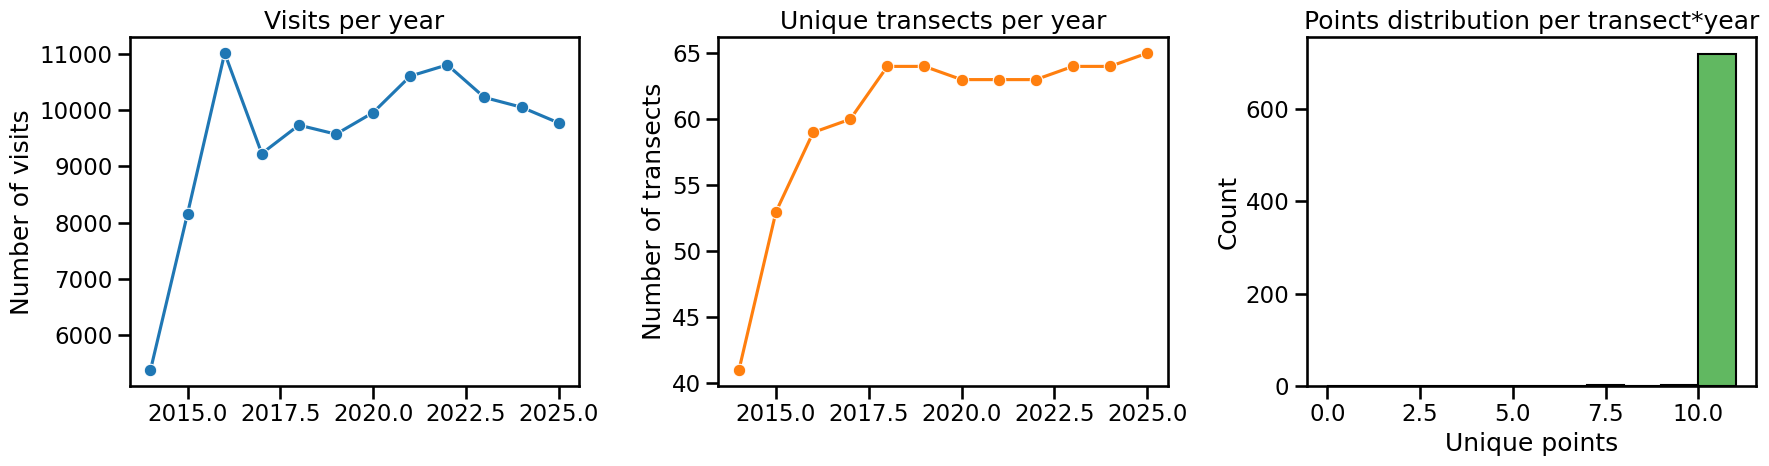

In [89]:
# Create effort metrics plots in a single row (1x3 grid)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Visits per year
ax = axes[0]
sns.lineplot(data=visits_per_year, x='year', y='n_visits', marker='o', ax=ax, color='C0')
ax.set_title("Visits per year")
ax.set_xlabel(""); ax.set_ylabel("Number of visits")

# 2. Unique transects per year
ax = axes[1]
sns.lineplot(data=transects_per_year, x='year', y='n_transects', marker='o', ax=ax, color='C1')
ax.set_title("Unique transects per year")
ax.set_xlabel(""); ax.set_ylabel("Number of transects")

# 3. Points distribution per transect*year
ax = axes[2]
sns.histplot(points_by_transect_year['unique_points'], bins=range(0, 12), color='C2', ax=ax)
ax.set_title("Points distribution per transect*year")
ax.set_xlabel("Unique points"); ax.set_ylabel("Count")

plt.tight_layout()
effort_metric_path = part_dir / "effort_metric.png"
plt.savefig(effort_metric_path)
plt.show()



### Categorical Variables Distribution

Plot frequency distributions for environmental and sampling condition variables (passage number, cloud cover, rain, wind, visibility). These categorical variables help assess data quality and potential biases related to weather or sampling protocol variations.


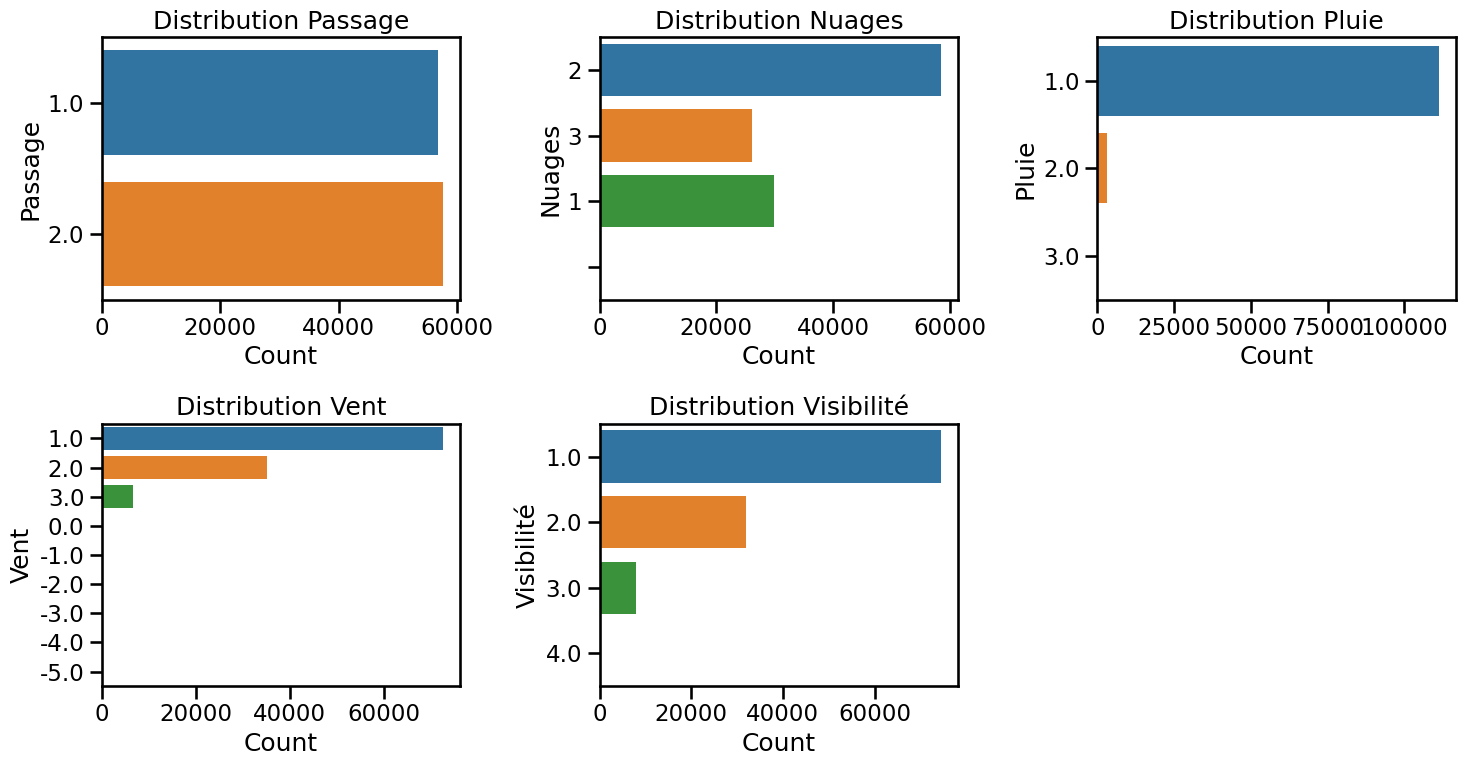

In [90]:
# Define categorical series from df_observations
candidate_map = {
    'Passage': [c for c in df_observations.columns if 'passage' in c.lower()],
    'Nuages': [c for c in df_observations.columns if 'nuage' in c.lower()],
    'Pluie': [c for c in df_observations.columns if 'pluie' in c.lower()],
    'Vent': [c for c in df_observations.columns if 'vent' in c.lower()],
    'Visibilité': [c for c in df_observations.columns if 'visibilit' in c.lower()],
}

cat_series = {
    label: df_observations[cands[0]].astype('string')
    for label, cands in candidate_map.items()
    if cands
}

# Create categorical distribution plots arranged over two rows
cat_series_clean = {label: serie.dropna() for label, serie in cat_series.items() if len(serie.dropna()) > 0}
n_cat = len(cat_series_clean)

if n_cat > 0:
    n_cols = (n_cat + 1) // 2  # ceiling division to distribute across two rows
    n_rows = 2 if n_cat > 1 else 1
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

    if n_rows == 1 and n_cols == 1:
        axes_list = [axes]
    elif n_rows == 1 or n_cols == 1:
        axes_list = list(axes)
    else:
        axes_list = [ax for row in axes for ax in row]

    for idx, (label, serie_clean) in enumerate(cat_series_clean.items()):
        ax = axes_list[idx]
        sns.countplot(y=serie_clean, ax=ax)
        ax.set_title(f"Distribution {label}")
        ax.set_xlabel("Count"); ax.set_ylabel(label)

    # Hide any unused subplots
    for idx in range(len(cat_series_clean), len(axes_list)):
        axes_list[idx].axis('off')

    plt.tight_layout()
    categorical_metric_path = part_dir / "categorical_metric.png"
    plt.savefig(categorical_metric_path)
    plt.show()
else:
    print("No valid categorical data to plot.")

### Temporal Coverage


In [91]:
# 1. Years with very low activity (visits << median)
visits_per_year = df_observations.groupby('year').size().rename('n_visits').reset_index()
median_visits = visits_per_year['n_visits'].median()
low_years = visits_per_year[visits_per_year['n_visits'] < median_visits * 0.6]
print("\nYears with low activity (<60% median visits):")
print(low_years if not low_years.empty else "No year with very low coverage.")



Years with low activity (<60% median visits):
   year  n_visits
0  2014      5378


In [92]:
# 2. Transect-year combinations with fewer than 10 points observed
col_transect = next(c for c in df_observations.columns if 'transect' in c.lower())
col_point = next(c for c in df_observations.columns if 'point' in c.lower())
points_by_transect_year = (
    df_observations.groupby(['year', col_transect])[col_point]
    .nunique()
    .reset_index()
    .rename(columns={col_point: 'nb_points'})
)
few_points = points_by_transect_year[points_by_transect_year['nb_points'] < 10]
print("\nTransect-years with <10 points observed (protocol = 10):")
print(few_points if not few_points.empty else "No cases.")



Transect-years with <10 points observed (protocol = 10):
     year     Nom transect  nb_points
297  2019   fonds préville          7
440  2021        lafayette          8
563  2023  ilets du robert          9
627  2024  ilets du robert          9
696  2025        lafayette          7


Generate a heatmap showing the number of unique observation points visited per year and per transect.

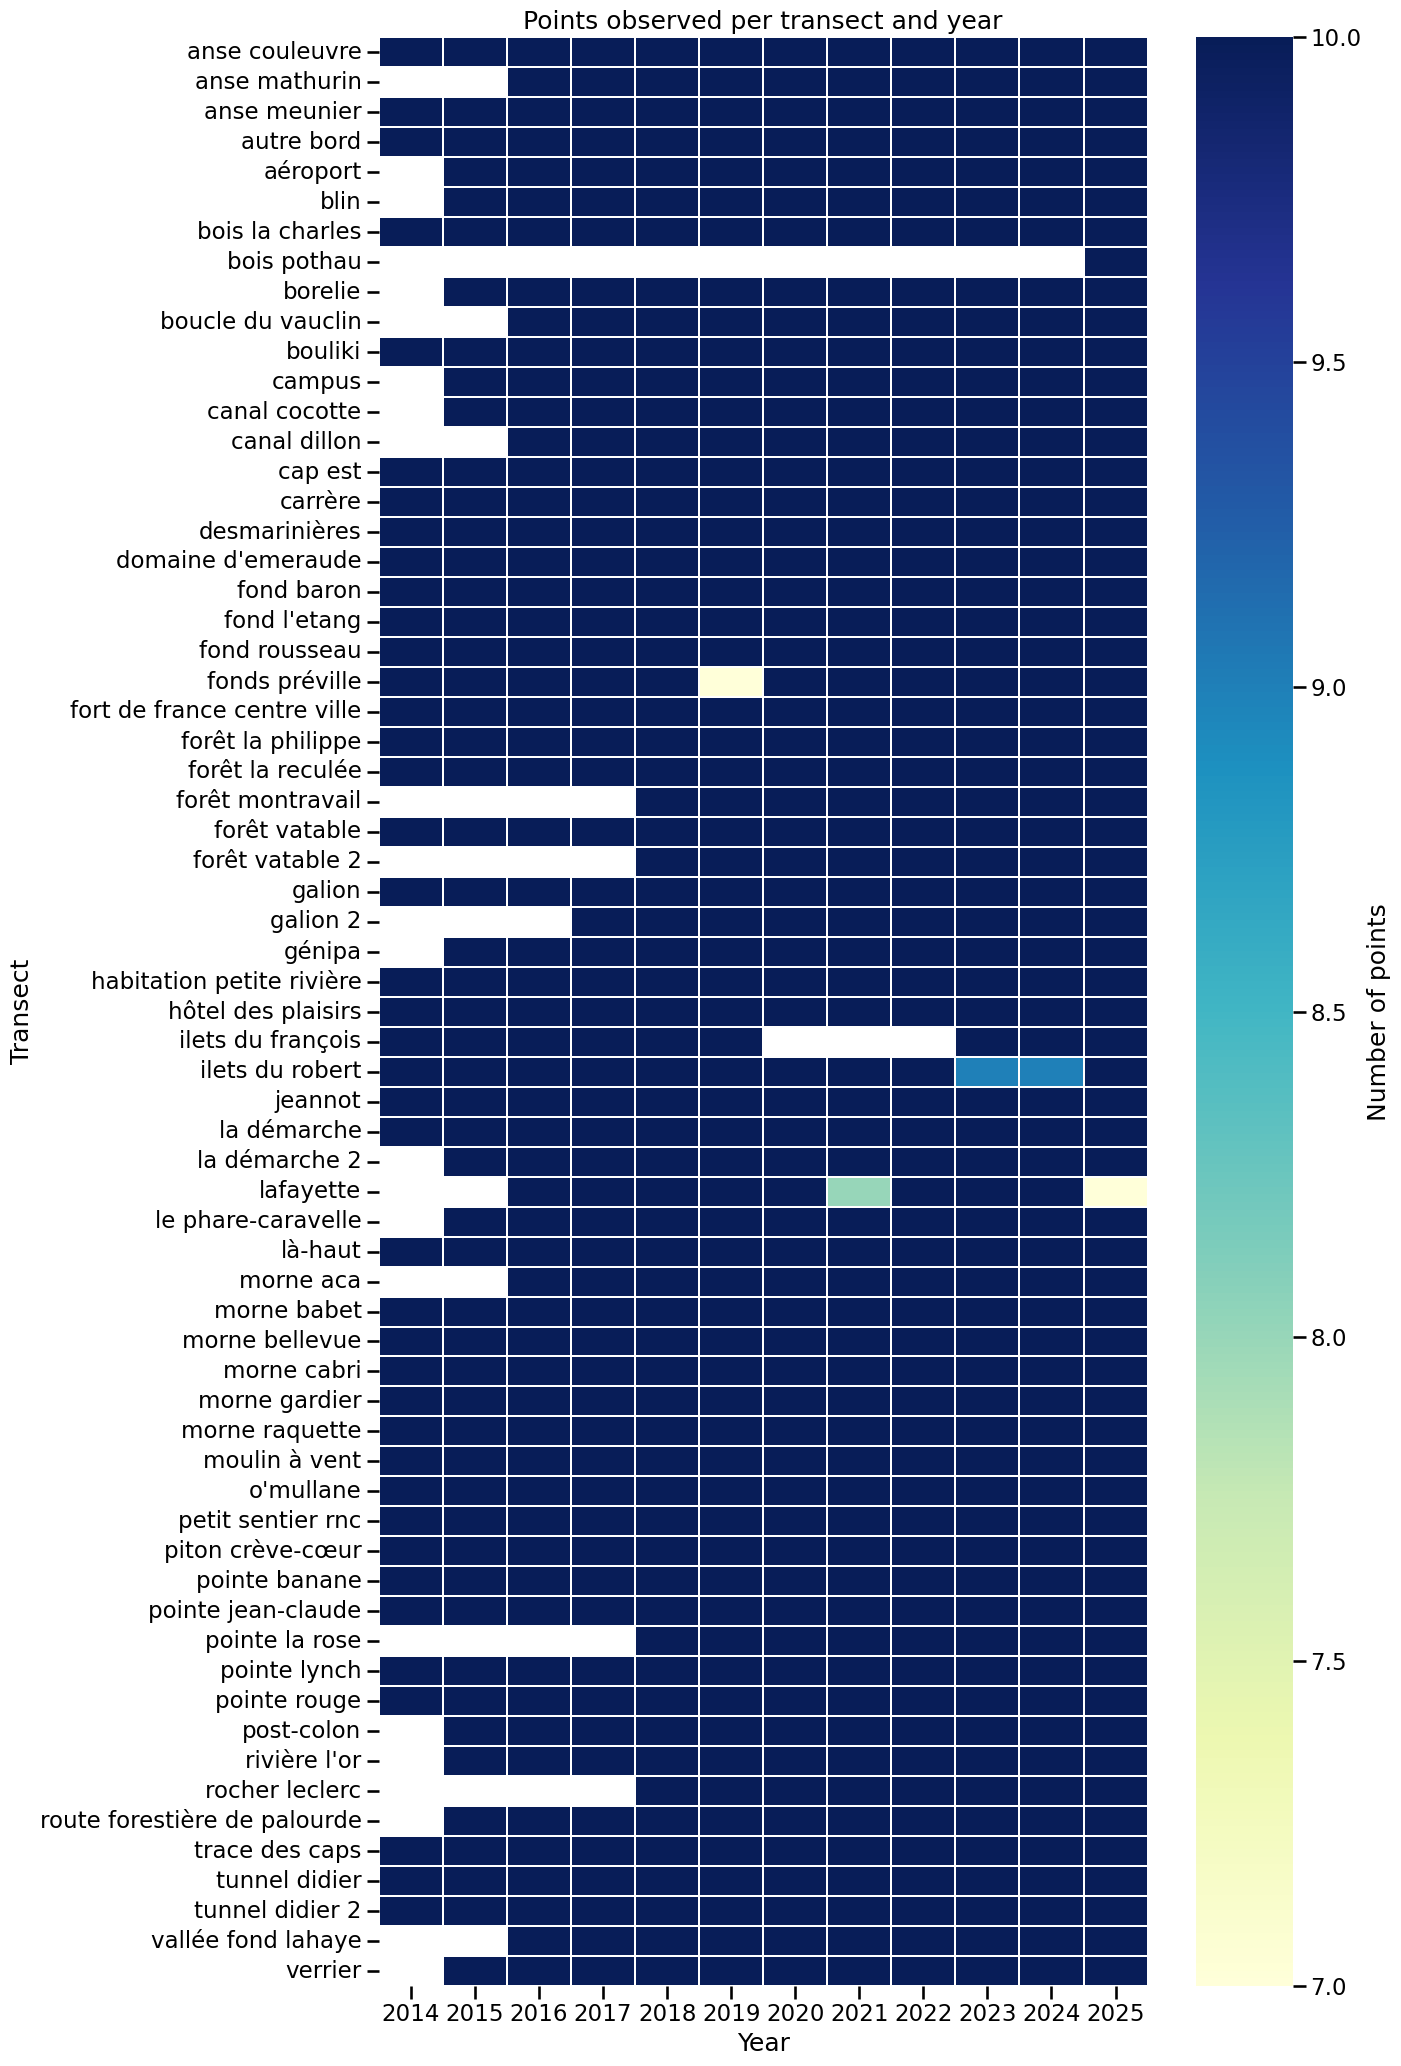

In [93]:
# Coverage heatmap 1
heatmap_saved = False
if not points_by_transect_year.empty and points_by_transect_year[col_transect].nunique()>1:
    pivot_cov = points_by_transect_year.pivot(index=col_transect, columns='year', values='nb_points')
    plt.figure(figsize=(14, max(6, pivot_cov.shape[0]//3)))
    sns.heatmap(pivot_cov, cmap='YlGnBu', linewidths=0.1, cbar_kws={'label': 'Number of points'})
    plt.title('Points observed per transect and year')
    plt.xlabel("Year")
    plt.ylabel("Transect")
    plt.tight_layout()
    heatmap_path = part_dir / "heatmap_points_par_transect_annee.png"
    plt.savefig(heatmap_path)
    heatmap_saved = True
    plt.show()
else:
    heatmap_path = None
    print("Not enough data for heatmaps.")


Generate a heatmap showing the total number of observations (all points combined) per year and per transect.

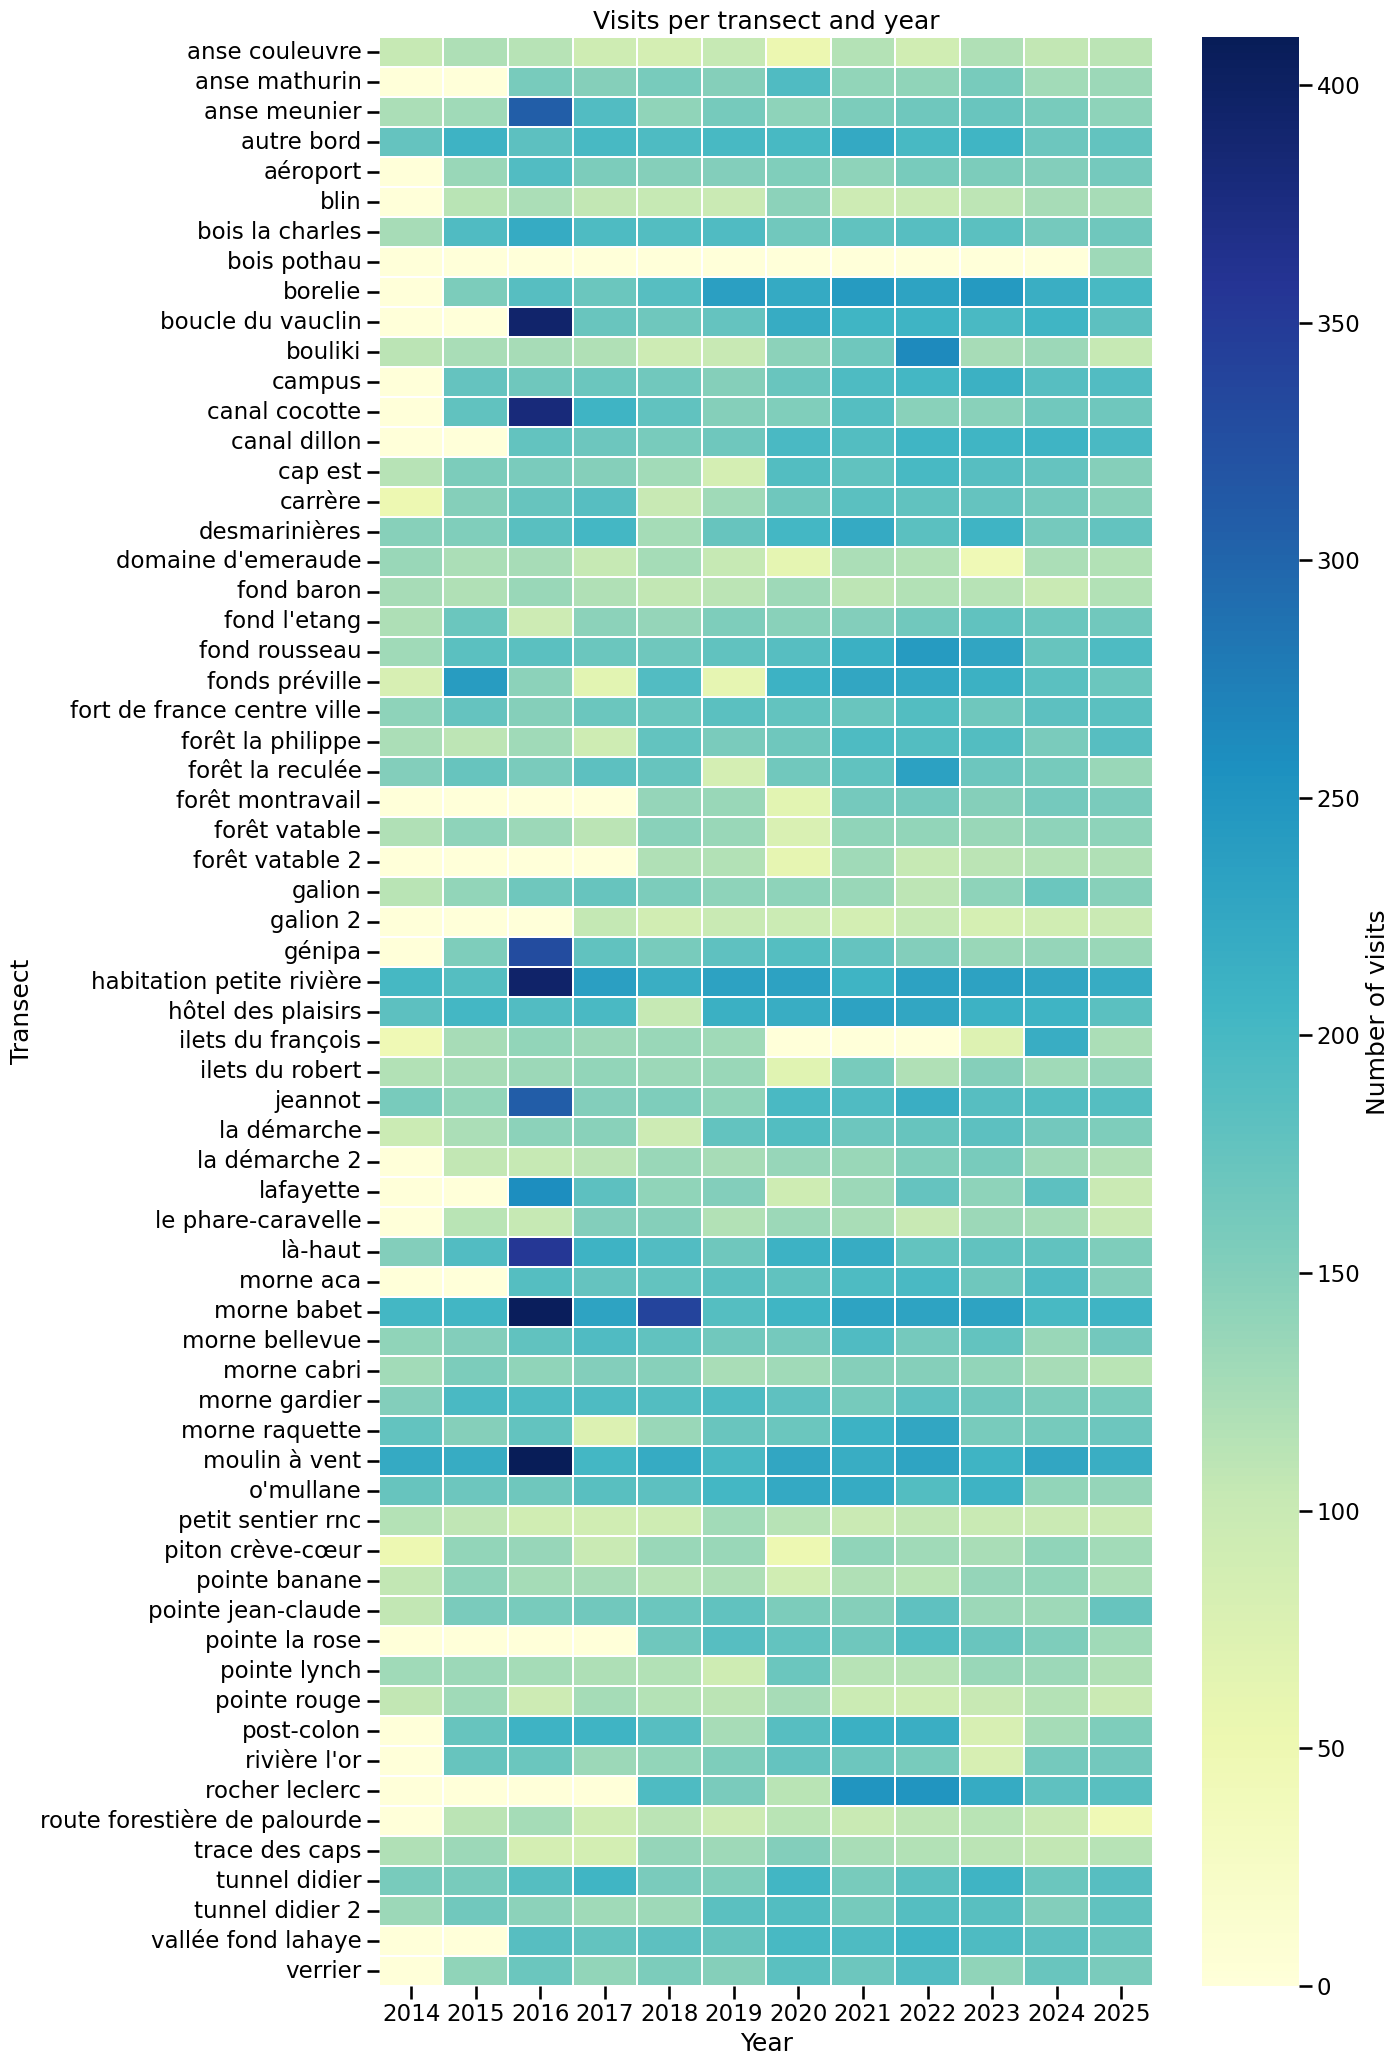

In [94]:
# Coverage heatmap 2 — Visits per transect and year
visits_heatmap_saved = False

# Number of visits (rows) per transect-year
visits_by_transect_year = (
    df_observations.groupby(['year', col_transect])
    .size()
    .rename('n_visits')
    .reset_index()
)

if not visits_by_transect_year.empty and visits_by_transect_year[col_transect].nunique() > 1:
    pivot_visits = visits_by_transect_year.pivot(index=col_transect, columns='year', values='n_visits').fillna(0)
    plt.figure(figsize=(14, max(6, pivot_visits.shape[0]//3)))
    sns.heatmap(pivot_visits, cmap='YlGnBu', linewidths=0.1, cbar_kws={'label': 'Number of visits'})
    plt.title('Visits per transect and year')
    plt.xlabel('Year')
    plt.ylabel('Transect')
    plt.tight_layout()
    visits_heatmap_path = part_dir / 'heatmap_visites_par_transect_annee.png'
    plt.savefig(visits_heatmap_path)
    visits_heatmap_saved = True
    plt.show()
else:
    visits_heatmap_path = None
    print('Not enough data for visits heatmap.')


## Clean


In [95]:
# Data cleaning: remove problematic observations
# Keep track of removed rows with reasons

# Initialize tracking
removed_rows = []
df_clean = df_observations.copy()

# Identify key columns first
col_transect = next(c for c in df_clean.columns if 'transect' in c.lower())
col_point = next(c for c in df_clean.columns if 'point' in c.lower())

# 1. Remove all observations from year 2014 (60% below median)
mask_2014 = df_clean['year'] == 2014
rows_2014 = df_clean[mask_2014].index.tolist()
for idx in rows_2014:
    removed_rows.append({
        'index': int(idx),
        'reason': 'Year 2014 (40% below median visits)',
        'year': 2014,
        'transect': df_clean.loc[idx, col_transect] if col_transect in df_clean.columns else 'N/A'
    })
df_clean = df_clean[~mask_2014]
print(f"1. Removed {len(rows_2014)} observations from year 2014")

# 2. Identify transects that didn't have 10 points visited at least 6 times
# (based on heatmap 1: points_by_transect_year)
# We need to recompute this after removing 2014

points_by_transect_year_clean = (
    df_clean.groupby(['year', col_transect])[col_point]
    .nunique()
    .reset_index()
    .rename(columns={col_point: 'nb_points'})
)

# For each transect, count how many years it had at least 10 points
transect_years_ok = (
    points_by_transect_year_clean[points_by_transect_year_clean['nb_points'] >= 10]
    .groupby(col_transect)
    .size()
    .rename('years_with_10_points')
)

# Transects that had < 6 years with 10 points
transects_to_remove_1 = transect_years_ok[transect_years_ok < 6].index.tolist()

mask_transects_1 = df_clean[col_transect].isin(transects_to_remove_1)
rows_transects_1 = df_clean[mask_transects_1].index.tolist()
for idx in rows_transects_1:
    transect_name = df_clean.loc[idx, col_transect]
    removed_rows.append({
        'index': int(idx),
        'reason': f'Transect <6 years with 10 points: {transect_name}',
        'year': int(df_clean.loc[idx, 'year']),
        'transect': transect_name
    })
df_clean = df_clean[~mask_transects_1]
print(f"2. Removed {len(rows_transects_1)} observations from {len(transects_to_remove_1)} transects with <6 years having 10 points")

# 3. Identify transects with low average visits (based on heatmap 2)
# Compute average visits per transect across all years
visits_by_transect_clean = (
    df_clean.groupby([col_transect, 'year'])
    .size()
    .rename('n_visits')
    .reset_index()
)

avg_visits_per_transect = visits_by_transect_clean.groupby(col_transect)['n_visits'].mean()
median_avg_visits = avg_visits_per_transect.median()
# Use 50% of median as threshold (adjustable)
threshold_visits = median_avg_visits * 0.5

transects_to_remove_2 = avg_visits_per_transect[avg_visits_per_transect < threshold_visits].index.tolist()
# Remove transects already removed in step 2
transects_to_remove_2 = [t for t in transects_to_remove_2 if t not in transects_to_remove_1]

mask_transects_2 = df_clean[col_transect].isin(transects_to_remove_2)
rows_transects_2 = df_clean[mask_transects_2].index.tolist()
for idx in rows_transects_2:
    transect_name = df_clean.loc[idx, col_transect]
    removed_rows.append({
        'index': int(idx),
        'reason': f'Transect low avg visits (<{threshold_visits:.1f}): {transect_name}',
        'year': int(df_clean.loc[idx, 'year']),
        'transect': transect_name
    })
df_clean = df_clean[~mask_transects_2]
print(f"3. Removed {len(rows_transects_2)} observations from {len(transects_to_remove_2)} transects with low average visits (<{threshold_visits:.1f})")
print(f"\nThreshold used: {threshold_visits:.1f} visits (50% of median: {median_avg_visits:.1f})")

# Summary
print(f"\n=== Cleaning Summary ===")
print(f"Original dataset: {len(df_observations)} rows")
print(f"Cleaned dataset: {len(df_clean)} rows")
print(f"Total rows removed: {len(removed_rows)} rows")
print(f"Removal rate: {len(removed_rows)/len(df_observations)*100:.1f}%")

# Create summary table of removed rows
if removed_rows:
    df_removed = pd.DataFrame(removed_rows)
    print(f"\n=== Summary of Removed Rows ===")
    print(f"Total unique rows removed: {df_removed['index'].nunique()}")
    print(f"\nBreakdown by reason:")
    print(df_removed['reason'].value_counts())
    print(f"\nFirst 50 removed rows (showing index, year, transect, reason):")
    print(df_removed[['index', 'year', 'transect', 'reason']].head(50).to_string(index=False))

    # Save removed rows to CSV
    df_removed.to_csv(RES_DIR / 'removed_rows_clean.csv', index=False)
    print(f"\nFull list of removed rows saved to: {RES_DIR / 'removed_rows_clean.csv'}")
else:
    print("\nNo rows were removed.")


1. Removed 5378 observations from year 2014
2. Removed 132 observations from 1 transects with <6 years having 10 points
3. Removed 0 observations from 0 transects with low average visits (<80.2)

Threshold used: 80.2 visits (50% of median: 160.5)

=== Cleaning Summary ===
Original dataset: 114495 rows
Cleaned dataset: 108985 rows
Total rows removed: 5510 rows
Removal rate: 4.8%

=== Summary of Removed Rows ===
Total unique rows removed: 5510

Breakdown by reason:
reason
Year 2014 (40% below median visits)              5378
Transect <6 years with 10 points: bois pothau     132
Name: count, dtype: int64

First 50 removed rows (showing index, year, transect, reason):
 index  year     transect                              reason
     2  2014 fond l'etang Year 2014 (40% below median visits)
     3  2014 fond l'etang Year 2014 (40% below median visits)
     4  2014 fond l'etang Year 2014 (40% below median visits)
     5  2014 fond l'etang Year 2014 (40% below median visits)
     6  2014 fond

In [96]:
df_observations=df_clean

# Part 2 : Multi-Year Indicator Trends

In [97]:
FIG_DIR = ROOT / "figures" / "part_2"
RES_DIR = ROOT / "results" / "part_2"

FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

### Data preparation & Aggregation

To compute indicators.


Select the preferred count column, aggregate observations by species and year.


In [98]:
# Preparation: row-level counts and species-year aggregation
from collections import defaultdict

# Individual counter choice: prioritize "Totaux audio+visuel sans Vol" if present,
# otherwise use "Totaux Audio+visuel avec Vol", failing that "Totaux visuel sans Vol", else 0.
count_cols_priority = [
    'Totaux audio+visuel sans Vol',
    'Totaux Audio+visuel avec Vol',
    'Totaux visuel sans Vol',
]

# Ensure these columns are numeric if present
for c in count_cols_priority:
    if c in df_observations.columns:
        df_observations[c] = pd.to_numeric(df_observations[c], errors='coerce')

# Create preferred count column
def select_count_row(row):
    """
    Select the preferred count value from a row based on column priority.

    Args:
        row (pd.Series): DataFrame row containing count columns

    Returns:
        float: Selected count value, or 0.0 if all columns are missing
    """
    for c in count_cols_priority:
        if c in row.index and pd.notna(row[c]):
            return row[c]
    return 0.0

df_observations['count_preferred'] = df_observations.apply(select_count_row, axis=1).astype(float)

# Temporal coverage
years_present = sorted(df_observations['year'].dropna().unique().astype(int))
years_list = [int(y) for y in years_present]

# Species-year aggregation
species_col = 'ESPECE'
counts_species_year = (
    df_observations.dropna(subset=['year', species_col])
    .groupby(['year', species_col], as_index=False)['count_preferred']
    .sum()
)

# Build species x year matrix for diversity calculations
pivot_counts = counts_species_year.pivot(index='year', columns=species_col, values='count_preferred').fillna(0.0)
n_species = pivot_counts.shape[1]

print(f"\nSpecies-year matrix: {pivot_counts.shape[0]} years x {n_species} species")
print(f"Total observations aggregated: {int(df_observations['count_preferred'].sum())}")


Species-year matrix: 11 years x 102 species
Total observations aggregated: 237018


### Biodiversity indicator 1 & 2: Species richness and Total abundance

Compute annual species richness (number of species observed) and total abundance (sum of individuals counted).


In [99]:
# Compute species richness per year
richness_year = (
    counts_species_year[counts_species_year['count_preferred'] > 0]
    .groupby('year', as_index=False)[species_col]
    .nunique()
    .rename(columns={species_col: 'richness'})
)

# Compute total abundance per year
total_counts_year = (
    counts_species_year
    .groupby('year', as_index=False)['count_preferred']
    .sum()
    .rename(columns={'count_preferred': 'abundance_total'})
)

print("Annual richness and abundance computed:")
print(f"  Richness range: {richness_year['richness'].min():.0f} - {richness_year['richness'].max():.0f} species")
print(f"  Abundance range: {total_counts_year['abundance_total'].min():.0f} - {total_counts_year['abundance_total'].max():.0f} individuals")


Annual richness and abundance computed:
  Richness range: 64 - 74 species
  Abundance range: 17319 - 24417 individuals


### Biodiversity Indicator 3 & 4: Shannon & Simpson Indices

Define Shannon and Simpson diversity indices for computing community evenness and diversity from species count data.


In [100]:
from math import log

def shannon_index(counts: np.ndarray) -> float:
    """
    Calculate Shannon diversity index.
    Formula: H = -sum(p_i * log(p_i))

    Args:
        counts (np.ndarray): Array of species counts

    Returns:
        float: Shannon diversity index (higher values = more diverse)
    """
    total = counts.sum()
    if total <= 0:
        return 0.0
    p = counts[counts > 0] / total
    return float(-(p * np.log(p)).sum())

def simpson_index(counts: np.ndarray) -> float:
    """
    Calculate Simpson diversity index (1 - D).
    Formula: 1 - sum(p_i^2), where p_i are relative abundances

    Args:
        counts (np.ndarray): Array of species counts

    Returns:
        float: Simpson diversity index (higher values = more diverse)
    """
    total = counts.sum()
    if total <= 0:
        return 0.0
    p = counts / total
    D = float((p * p).sum())
    return 1.0 - D


.. and now compute previous indices for each year using aggregated species counts.


In [101]:
# Calculate diversity indices for each year
diversity_rows = []
for yr, row in pivot_counts.iterrows():
    c = row.values.astype(float)
    diversity_rows.append({
        'year': int(yr),
        'shannon': shannon_index(c),
        'simpson_1mD': simpson_index(c),
    })

diversity_year = pd.DataFrame(diversity_rows)
diversity_year


,year,shannon,simpson_1mD
0,2015,3.048411,0.926885
1,2016,3.045182,0.926049
2,2017,3.016931,0.925107
3,2018,2.994555,0.923016
4,2019,3.011231,0.924496
5,2020,3.039662,0.928024
6,2021,3.039925,0.928683
7,2022,3.030524,0.929513
8,2023,3.053052,0.930277
9,2024,3.030088,0.927285


### Bootstrap Confidence Intervals

Estimate 95% confidence intervals for all indicators using bootstrap resampling (resampling observation rows within each year, then recalculating indicators).


In [102]:
def bootstrap_indicator_year(df_obs_year: pd.DataFrame, n_boot: int = 500, random_state: int = 42):
    """
    Bootstrap biodiversity indicators for a single year.

    Resamples observation rows with replacement, re-aggregates by species,
    and recalculates all indicators to estimate 95% confidence intervals.

    Args:
        df_obs_year (pd.DataFrame): Observations for one year
        n_boot (int): Number of bootstrap iterations (default: 500)
        random_state (int): Random seed for reproducibility (default: 42)

    Returns:
        dict: Dictionary containing 95% CI tuples (low, high) for:
              - abundance_total_ci
              - richness_ci
              - shannon_ci
              - simpson_1mD_ci
    """
    rng = np.random.default_rng(random_state)
    n = len(df_obs_year)
    # Handle edge case: empty dataframe
    if n == 0:
        return {
            'abundance_total_ci': (np.nan, np.nan),
            'richness_ci': (np.nan, np.nan),
            'shannon_ci': (np.nan, np.nan),
            'simpson_1mD_ci': (np.nan, np.nan),
        }

    abundance_samples = []
    richness_samples = []
    shannon_samples = []
    simpson_samples = []

    # Bootstrap resampling: draw n rows with replacement, compute indicators
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)  # Resample row indices
        sample = df_obs_year.iloc[idx]
        species_counts = sample.groupby('ESPECE')['count_preferred'].sum()
        counts = species_counts.values.astype(float)
        abundance_samples.append(counts.sum())
        richness_samples.append((counts > 0).sum())
        shannon_samples.append(shannon_index(counts))
        simpson_samples.append(simpson_index(counts))

    # Helper to compute 95% CI from bootstrap distribution
    def q(ci_samples):
        lo, hi = np.percentile(ci_samples, [2.5, 97.5])
        return float(lo), float(hi)

    return {
        'abundance_total_ci': q(abundance_samples),
        'richness_ci': q(richness_samples),
        'shannon_ci': q(shannon_samples),
        'simpson_1mD_ci': q(simpson_samples),
    }


In [103]:
# Apply bootstrap to each year
rows_ci = []
for yr in years_present:
    df_y = df_observations[df_observations['year'] == yr]
    ci = bootstrap_indicator_year(df_y, n_boot=400, random_state=yr)
    rows_ci.append({'year': yr, **ci})
ci_df = pd.DataFrame(rows_ci)

# Merge all indicators and confidence intervals
indicators = (
    richness_year.merge(total_counts_year, on='year', how='outer')
    .merge(diversity_year, on='year', how='outer')
    .merge(ci_df, on='year', how='left')
    .sort_values('year')
)

print("Indicators with 95% CI:")
print(indicators.head())

Indicators with 95% CI:
   year  richness  abundance_total   shannon  simpson_1mD  \
0  2015        64     17319.000000  3.048411     0.926885   
1  2016        74     22888.000000  3.045182     0.926049   
2  2017        71     20520.285714  3.016931     0.925107   
3  2018        71     20325.000000  2.994555     0.923016   
4  2019        70     21015.333333  3.011231     0.924496   

                         abundance_total_ci   richness_ci  \
0                      (16896.9, 17752.325)  (58.0, 64.0)   
1                    (22457.975, 23405.375)  (67.0, 73.0)   
2   (20022.85714285714, 20987.953571428574)  (63.0, 70.0)   
3                    (19833.975, 20897.025)  (64.0, 70.0)   
4  (20509.016666666666, 21575.508333333335)  (63.0, 69.0)   

                                 shannon_ci  \
0  (2.9865914476579905, 3.0785493625804095)   
1   (3.005562581557011, 3.0737939057913652)   
2   (2.965758122107743, 3.0507380509311246)   
3  (2.9516757241154625, 3.0225872375733416)   
4  (2.9

Interpreting the indicators:
- **Richness**: Number of species observed (higher = greater diversity)
- **Abundance**: Total individuals counted (higher = more detections, but not necessarily "better")
- **Shannon Index**: Diversity combining richness and evenness (higher = more diverse and balanced community; typical range 1.5-3.5)
- **Simpson Index (1-D)**: Probability two random individuals are different species (higher = more diverse; range 0-1)

### Visualization: Indicators Over Time

Let's now display all four biodiversity indicators in a grid with confidence interval ribbons.


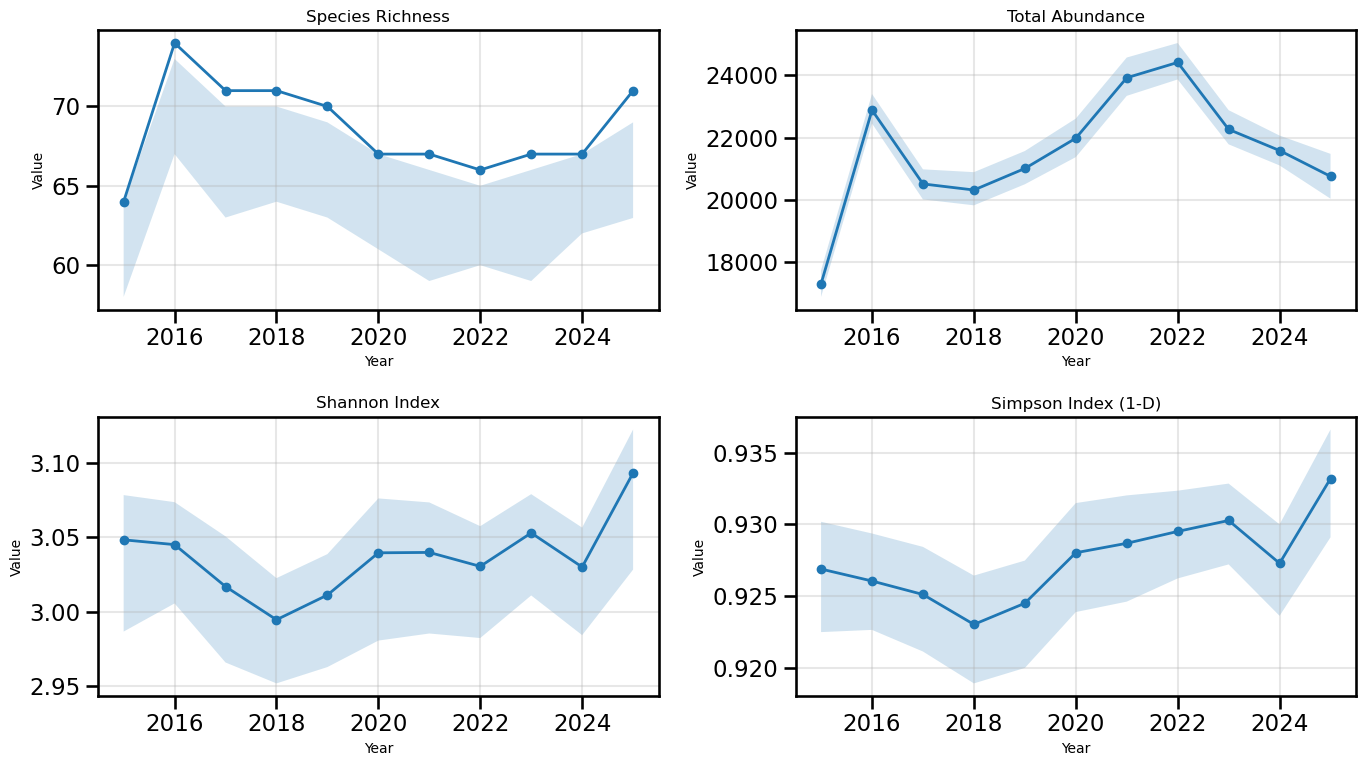

2x2 grid figure saved in figures\part_2\all_indicators_2x2.png


In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

indicators_to_plot = [
    ('richness', 'richness_ci', 'Species Richness'),
    ('abundance_total', 'abundance_total_ci', 'Total Abundance'),
    ('shannon', 'shannon_ci', 'Shannon Index'),
    ('simpson_1mD', 'simpson_1mD_ci', 'Simpson Index (1-D)')
]

axes_flat = axes.flatten()

for idx, (ind, ci_col, title) in enumerate(indicators_to_plot):
    ax = axes_flat[idx]
    sub = indicators[['year', ind, ci_col]].rename(columns={ind: 'estimate'})
    sub[['ci_low', 'ci_high']] = pd.DataFrame(sub[ci_col].tolist(), index=sub.index)

    ax.plot(sub['year'], sub['estimate'], marker='o', linewidth=2, markersize=6)
    ax.fill_between(sub['year'], sub['ci_low'], sub['ci_high'], alpha=0.2)
    ax.set_title(f"{title}", fontsize=12)
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('Value', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'all_indicators_2x2.png', dpi=200, bbox_inches='tight')
plt.show()

print('2x2 grid figure saved in', FIG_DIR / 'all_indicators_2x2.png')


### Temporal Trend Analysis

Estimate annual slopes for each indicator using linear regression, with bootstrap confidence intervals to quantify uncertainty in the trend direction.


In [105]:
def slope_bootstrap(years: np.ndarray, values: np.ndarray, n_boot: int = 2000, random_state: int = 0):
    """
    Estimate linear trend slope with bootstrap 95% confidence intervals (CI).

    Fits a simple linear regression and uses bootstrap resampling of
    (year, value) pairs to estimate uncertainty in the annual slope.

    Args:
        years (np.ndarray): Array of year values
        values (np.ndarray): Array of indicator values
        n_boot (int): Number of bootstrap iterations (default: 2000)
        random_state (int): Random seed for reproducibility (default: 0)

    Returns:
        tuple: (point_estimate, (ci_low, ci_high))
               - point_estimate (float): Linear regression slope
               - ci_low, ci_high (float): 95% CI bounds
    """
    rng = np.random.default_rng(random_state)
    x = years.astype(float) - years.min()  # Center years for numerical stability
    mask = np.isfinite(values)  # Remove NaN/Inf values
    x = x[mask]
    y = values[mask]
    if len(x) < 2:
        return np.nan, (np.nan, np.nan)

    b_point = np.polyfit(x, y, 1)[0]  # Point estimate of slope

    # Bootstrap resampling to estimate CI
    n = len(x)
    slopes = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)  # Resample (year, value) pairs with replacement
        bx = x[idx]
        by = y[idx]
        try:
            slopes.append(np.polyfit(bx, by, 1)[0])
        except Exception:  # Handle rare cases where polyfit fails
            continue
    if len(slopes) == 0:
        return float(b_point), (np.nan, np.nan)
    lo, hi = np.percentile(slopes, [2.5, 97.5])  # 95% CI from bootstrap distribution
    return float(b_point), (float(lo), float(hi))


In [106]:
# Compute trends for all indicators
trend_rows = []
for ind_col in ['richness', 'abundance_total', 'shannon', 'simpson_1mD']:
    years = indicators['year'].values
    vals = indicators[ind_col].values
    slope, (lo, hi) = slope_bootstrap(years, vals, n_boot=2000, random_state=123)
    trend_rows.append({
        'indicator': ind_col,
        'slope_per_year': slope,
        'slope_ci_low': lo,
        'slope_ci_high': hi,
    })
trends_df = pd.DataFrame(trend_rows)
print("\nTemporal trends (annual slope ± 95% CI):")
print(trends_df)


Temporal trends (annual slope ± 95% CI):
         indicator  slope_per_year  slope_ci_low  slope_ci_high
0         richness       -0.163636     -1.016337       0.408528
1  abundance_total      257.925541   -113.254694     758.043582
2          shannon        0.003400     -0.001458       0.010054
3      simpson_1mD        0.000629      0.000222       0.001183


### Visualization: Indicators with Trend Lines

Plot each indicator with its fitted linear trend line overlaid on the confidence interval ribbon.


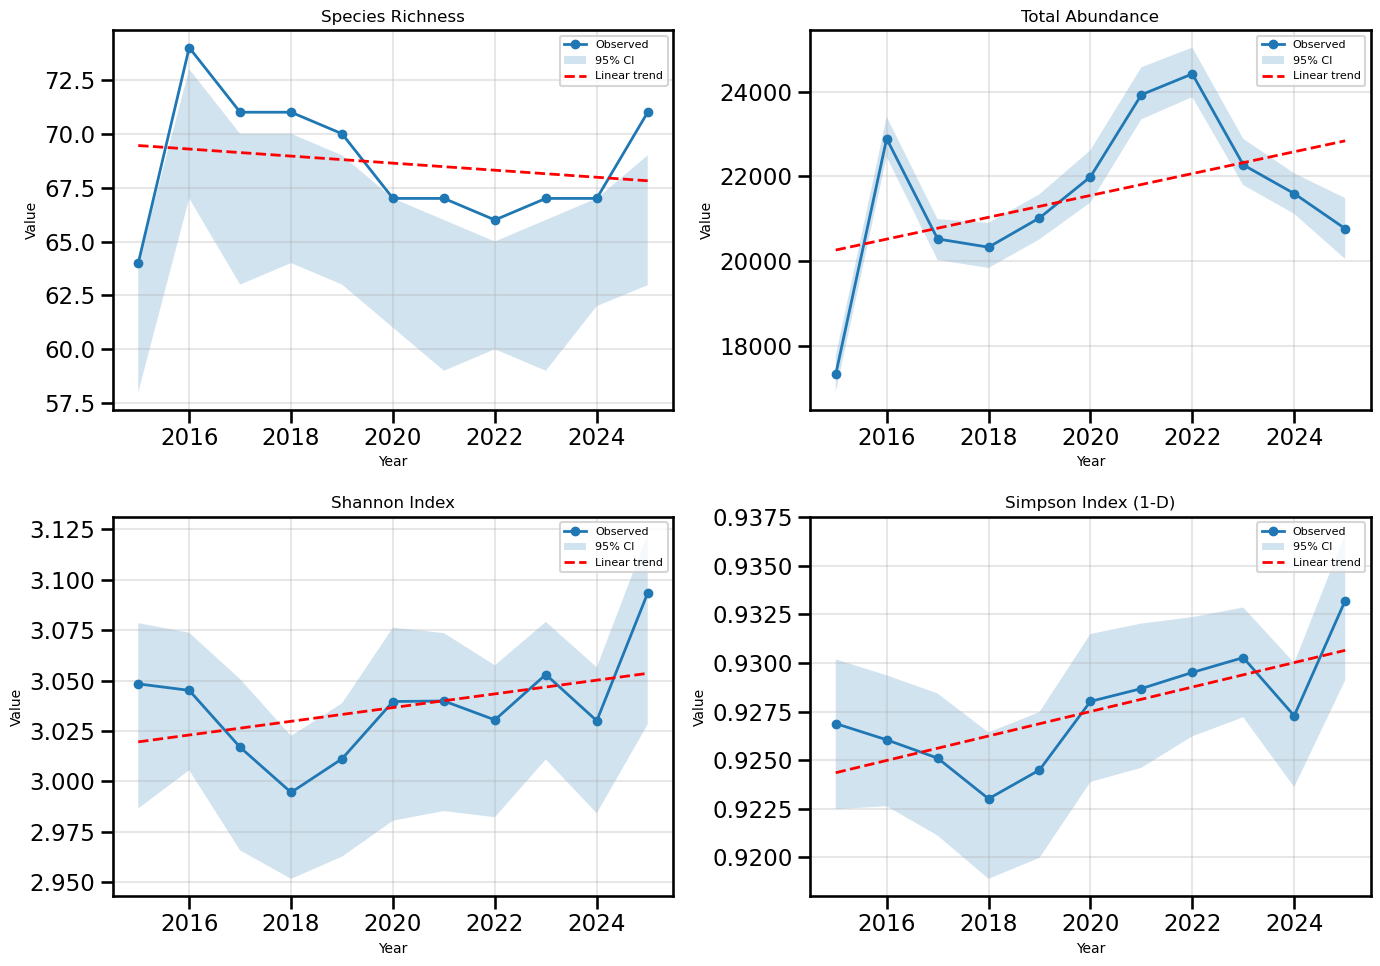

2x2 grid with trend lines saved to figures\part_2\all_indicators_with_trends_2x2.png


In [107]:
sns.set_context("talk")

# Create 2x2 grid for all indicators with trend lines
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

indicators_to_plot = [
    ('richness', 'richness_ci', 'Species Richness'),
    ('abundance_total', 'abundance_total_ci', 'Total Abundance'),
    ('shannon', 'shannon_ci', 'Shannon Index'),
    ('simpson_1mD', 'simpson_1mD_ci', 'Simpson Index (1-D)')
]

axes_flat = axes.flatten()

for idx, (ind, ci_col, title) in enumerate(indicators_to_plot):
    ax = axes_flat[idx]

    # Prepare data
    sub = indicators[['year', ind, ci_col]].rename(columns={ind: 'estimate'})
    sub[['ci_low', 'ci_high']] = pd.DataFrame(sub[ci_col].tolist(), index=sub.index)

    # Fit linear trend
    x0 = sub['year'].min()
    x = (sub['year'] - x0).astype(float)
    y = sub['estimate'].astype(float)
    mask = np.isfinite(x) & np.isfinite(y)
    b, a = np.polyfit(x[mask].values, y[mask].values, 1)
    y_hat = a + b * x

    # Plot
    ax.plot(sub['year'], sub['estimate'], marker='o', linewidth=2, markersize=6, label='Observed')
    ax.fill_between(sub['year'], sub['ci_low'], sub['ci_high'], alpha=0.2, label='95% CI')
    ax.plot(sub['year'], y_hat, color='red', linestyle='--', linewidth=2, label='Linear trend')
    ax.set_title(f"{title}", fontsize=12)
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('Value', fontsize=10)
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'all_indicators_with_trends_2x2.png', dpi=200, bbox_inches='tight')
plt.show()

print('2x2 grid with trend lines saved to', FIG_DIR / 'all_indicators_with_trends_2x2.png')


### Alternative Approach: LOESS Smoothing

While linear regression is interpretable, it assumes constant rates of change that may be unrealistic for ecological indicators responding to variable environmental drivers. With only 12 data points, a single unusual year can disproportionately affect the slope estimate. To complement the linear analysis, we use LOESS (Locally Weighted Scatterplot Smoothing) to reveal potential non-linear patterns without imposing a rigid functional form.


In [108]:
from statsmodels.nonparametric.smoothers_lowess import lowess

def loess_smooth_bootstrap(years, values, frac=0.5, n_boot=500, random_state=42):
    """
    Smooth time series with LOESS and estimate confidence bands via bootstrap.

    Args:
        years (np.ndarray): Year values
        values (np.ndarray): Indicator values
        frac (float): Fraction of data for local regression (default: 0.5)
        n_boot (int): Number of bootstrap iterations (default: 500)
        random_state (int): Random seed

    Returns:
        dict: Contains 'fitted' values and 'ci_low', 'ci_high' confidence bands
    """
    mask = np.isfinite(values)  # Remove NaN/Inf values
    x = years[mask].astype(float)
    y = values[mask]

    smoothed = lowess(y, x, frac=frac, return_sorted=False)  # LOESS fit on original data

    # Bootstrap resampling to estimate confidence bands
    rng = np.random.default_rng(random_state)
    n = len(x)
    boot_smoothed = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)  # Resample (year, value) pairs with replacement
        x_boot = x[idx]
        y_boot = y[idx]
        sort_idx = np.argsort(x_boot)  # LOESS requires sorted x-values
        x_sorted = x_boot[sort_idx]
        y_sorted = y_boot[sort_idx]

        try:
            smooth_boot = lowess(y_sorted, x_sorted, frac=frac, return_sorted=False)
            smooth_interp = np.interp(x, x_sorted, smooth_boot)  # Interpolate to original x grid
            boot_smoothed.append(smooth_interp)
        except:  # Handle rare cases where LOESS fails
            continue

    boot_smoothed = np.array(boot_smoothed)
    ci_low = np.percentile(boot_smoothed, 2.5, axis=0)  # 95% CI from bootstrap distribution
    ci_high = np.percentile(boot_smoothed, 97.5, axis=0)

    return {'years': x, 'fitted': smoothed, 'ci_low': ci_low, 'ci_high': ci_high}


In [109]:
print("Computing LOESS smoothing for all indicators...")

loess_results = {}
for ind_col in ['richness', 'abundance_total', 'shannon', 'simpson_1mD']:
    years_arr = indicators['year'].values
    vals_arr = indicators[ind_col].values
    loess_results[ind_col] = loess_smooth_bootstrap(years_arr, vals_arr, frac=0.6, n_boot=400, random_state=42)
    print(f"  {ind_col}: completed")

print("\nLOESS smoothing completed.")


Computing LOESS smoothing for all indicators...
  richness: completed
  abundance_total: completed
  shannon: completed
  simpson_1mD: completed

LOESS smoothing completed.


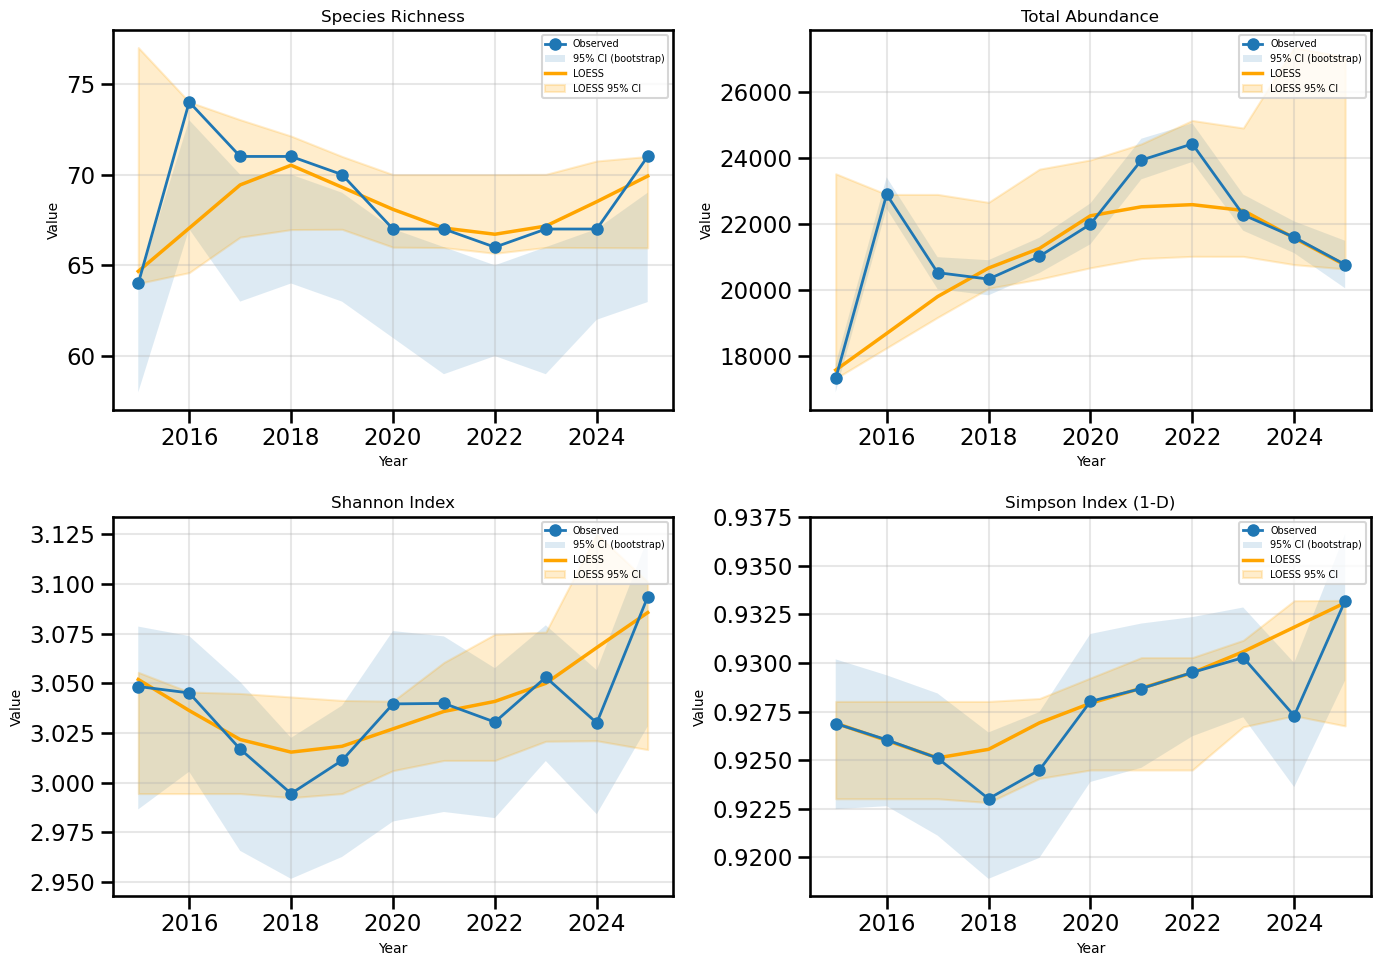

LOESS smoothing figure saved: figures\part_2\indicators_with_loess.png


In [110]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

indicators_to_plot = [
    ('richness', 'richness_ci', 'Species Richness'),
    ('abundance_total', 'abundance_total_ci', 'Total Abundance'),
    ('shannon', 'shannon_ci', 'Shannon Index'),
    ('simpson_1mD', 'simpson_1mD_ci', 'Simpson Index (1-D)')
]

axes_flat = axes.flatten()

for idx, (ind, ci_col, title) in enumerate(indicators_to_plot):
    ax = axes_flat[idx]

    # Observed data with CI
    sub = indicators[['year', ind, ci_col]].rename(columns={ind: 'estimate'})
    sub[['ci_low', 'ci_high']] = pd.DataFrame(sub[ci_col].tolist(), index=sub.index)

    ax.plot(sub['year'], sub['estimate'], 'o-', markersize=8, label='Observed', linewidth=2, zorder=3)
    ax.fill_between(sub['year'], sub['ci_low'], sub['ci_high'], alpha=0.15, label='95% CI (bootstrap)')

    # LOESS smooth
    loess_data = loess_results[ind]
    ax.plot(loess_data['years'], loess_data['fitted'], '-', color='orange', linewidth=2.5, label='LOESS', zorder=2)
    ax.fill_between(loess_data['years'], loess_data['ci_low'], loess_data['ci_high'],
                     alpha=0.2, color='orange', label='LOESS 95% CI')

    ax.set_title(f"{title}", fontsize=12)
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('Value', fontsize=10)
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'indicators_with_loess.png', dpi=200, bbox_inches='tight')
plt.show()

print('LOESS smoothing figure saved:', FIG_DIR / 'indicators_with_loess.png')

### LOESS Smoothing: 

- **Method**: Local weighted regressions using nearby data points; trends curve naturally without assuming a specific form
- **Smoothing parameter** (frac=0.6): Controls bandwidth—higher values = smoother curves
- **Why LOESS**: Suited for ecological indicators responding non-linearly to environmental drivers (see report for details)
- **Confidence bands**: Bootstrap CIs distinguish genuine patterns from noise


### Export Results & Methodology Documentation

Save all computed indicators and trends to CSV files, and generate a markdown document describing the methodology.


In [111]:
# Part 2 — Export results and brief justification text

# Export tables
indicators.to_csv(RES_DIR / 'indicators_annual_with_ci.csv', index=False)
trends_df.to_csv(RES_DIR / 'indicators_trends_linear.csv', index=False)

# Export LOESS smoothed results
loess_export = []
for ind_col in ['richness', 'abundance_total', 'shannon', 'simpson_1mD']:
    loess_data = loess_results[ind_col]
    for i, yr in enumerate(loess_data['years']):
        loess_export.append({
            'year': int(yr),
            'indicator': ind_col,
            'loess_fitted': loess_data['fitted'][i],
            'loess_ci_low': loess_data['ci_low'][i],
            'loess_ci_high': loess_data['ci_high'][i]
        })
loess_df = pd.DataFrame(loess_export)
loess_df.to_csv(RES_DIR / 'indicators_trends_loess.csv', index=False)

print('Exports:')
print(' -', RES_DIR / 'indicators_annual_with_ci.csv')
print(' -', RES_DIR / 'indicators_trends_linear.csv')
print(' -', RES_DIR / 'indicators_trends_loess.csv')


Exports:
 - results\part_2\indicators_annual_with_ci.csv
 - results\part_2\indicators_trends_linear.csv
 - results\part_2\indicators_trends_loess.csv


# Part 3 : Species level evolution

In [112]:
FIG_DIR = ROOT / "figures" / "part_3"
RES_DIR = ROOT / "results" / "part_3"

FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

### Selection of a subset of interesting species

In [113]:

MIN_YEARS = 6        # at least 6 years with data
MIN_ROWS_TOTAL = 50   # at least 50 observation rows total

base_sp = df_observations.dropna(subset=['year', 'ESPECE']).copy()

# Coverage per species
coverage = (
    base_sp.groupby('ESPECE')
    .agg(years_with_data=('year', lambda s: s.nunique()), total_rows=('ESPECE', 'size'))
    .reset_index()
)
eligible = coverage[(coverage['years_with_data'] >= MIN_YEARS) & (coverage['total_rows'] >= MIN_ROWS_TOTAL)]
eligible_species = set(eligible['ESPECE'])

# 1) Top species by total abundance among eligible
species_tot = (
    base_sp[base_sp['ESPECE'].isin(eligible_species)]
    .groupby('ESPECE', as_index=False)['count_preferred']
    .sum()
    .rename(columns={'count_preferred': 'count_total'})
    .sort_values('count_total', ascending=False)
)

# Identify habitat column in df_gps_milieu
hab_col = None
cand_cols = [c for c in df_gps_milieu.columns if c not in ['Transect', 'X', 'Y', 'site_id', 'point_local_id']]
for c in cand_cols:
    if df_gps_milieu[c].notna().sum() > 0 and df_gps_milieu[c].astype(str).str.len().mean() > 2:
        hab_col = c
        break
# Mapping transect -> habitat (mode)
transect_col_gps = 'Transect' if 'Transect' in df_gps_milieu.columns else cand_cols[0]
if hab_col is not None:
    gps_hab = (
        df_gps_milieu.dropna(subset=[transect_col_gps, hab_col])
        .groupby(transect_col_gps)[hab_col]
        .agg(lambda s: s.mode().iat[0] if not s.mode().empty else s.dropna().iloc[0])
        .reset_index()
        .rename(columns={transect_col_gps: 'Nom transect', hab_col: 'habitat'})
    )
    base_sp = base_sp.merge(gps_hab, on='Nom transect', how='left')
else:
    base_sp['habitat'] = np.nan

# 2a) Habitat specificity: compute share per habitat per species (weighted by count_preferred)
_tmp = (
    base_sp[base_sp['ESPECE'].isin(eligible_species)]
    .dropna(subset=['habitat'])
    .groupby(['ESPECE', 'habitat'], as_index=False)['count_preferred']
    .sum()
)
_tmp['share'] = _tmp.groupby('ESPECE')['count_preferred'].transform(lambda s: s / s.sum())
hab_share = _tmp[['ESPECE', 'habitat', 'share']]
# Score: maximum share per species
hab_max = hab_share.groupby('ESPECE', as_index=False)['share'].max().rename(columns={'share': 'habitat_max_share'})
# Specialists (>=0.7) and generalists (<=0.4)
specialists = hab_max[hab_max['habitat_max_share'] >= 0.7]['ESPECE'].tolist()
generalists = hab_max[hab_max['habitat_max_share'] <= 0.4]['ESPECE'].tolist()

# 2b) Detection modality dependence: Audio vs Visual share per species
mod_cols = []
if 'Totaux auditif' in base_sp.columns and 'Totaux visuel sans Vol' in base_sp.columns:
    # Coerce to numeric to avoid summing strings
    base_sp['Totaux auditif'] = pd.to_numeric(base_sp['Totaux auditif'], errors='coerce')
    base_sp['Totaux visuel sans Vol'] = pd.to_numeric(base_sp['Totaux visuel sans Vol'], errors='coerce')
    mod = (
        base_sp[base_sp['ESPECE'].isin(eligible_species)]
        .groupby('ESPECE')[['Totaux auditif', 'Totaux visuel sans Vol']]
        .sum(min_count=1)
        .reset_index()
    )
    denom = (mod['Totaux auditif'] + mod['Totaux visuel sans Vol']).replace(0, np.nan)
    mod['audio_share'] = mod['Totaux auditif'] / denom
    audio_dom = mod[mod['audio_share'] >= 0.8]['ESPECE'].tolist()
    visual_dom = mod[mod['audio_share'] <= 0.2]['ESPECE'].tolist()
else:
    audio_dom, visual_dom = [], []




In [114]:
# Automatic selection: top 5 abundant + 2 habitat specialists + 2 modality (audio/visual)
reasons = {}

top_abundant = list(species_tot.head(5)['ESPECE'])
for s in top_abundant:
    reasons[s] = 'Top abundance'

hab_pick = [s for s in specialists if s in eligible_species and s not in top_abundant][:2]
for s in hab_pick:
    reasons[s] = 'Habitat specialist'

mod_pick = []
for s in audio_dom:
    if s in eligible_species and s not in top_abundant and s not in hab_pick:
        mod_pick.append(s)
        reasons[s] = 'Modality dependence (audio)'
        if len(mod_pick) >= 1:
            break
for s in visual_dom:
    if s in eligible_species and s not in top_abundant and s not in hab_pick and s not in mod_pick:
        mod_pick.append(s)
        reasons[s] = 'Modality dependence (visual)'
        if len(mod_pick) >= 2:
            break

selected_species = top_abundant + hab_pick + mod_pick
selected_species = [s for s in dict.fromkeys(selected_species) if s in eligible_species]

species_reason = {s: reasons.get(s, 'Eligible') for s in selected_species}
# Annotate habitat class if known
for s in selected_species:
    if s in specialists and 'Habitat specialist' not in species_reason[s]:
        species_reason[s] = species_reason[s] + ('; ' if species_reason[s] else '') + 'Habitat specialist'
    if s in generalists:
        species_reason[s] = species_reason[s] + ('; ' if species_reason[s] else '') + 'Habitat generalist'

print('Criteria: MIN_YEARS=', MIN_YEARS, 'MIN_ROWS_TOTAL=', MIN_ROWS_TOTAL)
print('Selected species (auto):', selected_species)
print('Reasons:', species_reason)


Criteria: MIN_YEARS= 6 MIN_ROWS_TOTAL= 50
Selected species (auto): ['Quiscale merle', 'Sucrier à ventre jaune', 'Elénie siffleuse', 'Tourterelle à queue carrée', 'Sporophile rougegorge', 'Colombe rouviolette', 'Aigrette neigeuse']
Reasons: {'Quiscale merle': 'Top abundance', 'Sucrier à ventre jaune': 'Top abundance', 'Elénie siffleuse': 'Top abundance', 'Tourterelle à queue carrée': 'Top abundance', 'Sporophile rougegorge': 'Top abundance', 'Colombe rouviolette': 'Modality dependence (audio)', 'Aigrette neigeuse': 'Modality dependence (visual)'}


### Annual species series: count and presence, with 95% CI


In [115]:

def presence_rate(series_counts: pd.Series) -> float:
    # presence = proportion of rows with count_preferred > 0 among all visits of the year (for the species)
    if series_counts.size == 0:
        return np.nan
    return float((series_counts > 0).sum() / series_counts.size)

# Prepare base: rows by year and species
base = df_observations.dropna(subset=['year', 'ESPECE']).copy()

# Compute point-estimate per species and year
rows = []
for sp in selected_species:
    df_sp = base[base['ESPECE'] == sp]
    for yr, g in df_sp.groupby('year'):
        rows.append({
            'ESPECE': sp,
            'year': int(yr),
            'count_sum': float(g['count_preferred'].sum()),
            'presence_rate': presence_rate(g['count_preferred']),
            'n_rows': int(len(g)),
        })
sp_annual = pd.DataFrame(rows)

# Bootstrap 95% CI per species and year

def bootstrap_species_year(df_sp_year: pd.DataFrame, n_boot: int = 400, random_state: int = 42):
    rng = np.random.default_rng(random_state)
    n = len(df_sp_year)
    if n == 0:
        return (np.nan, np.nan), (np.nan, np.nan)
    counts_ci = []
    pres_ci = []
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        samp = df_sp_year.iloc[idx]
        counts_ci.append(float(samp['count_preferred'].sum()))
        pres_ci.append(presence_rate(samp['count_preferred']))
    lo_c, hi_c = np.percentile(counts_ci, [2.5, 97.5])
    lo_p, hi_p = np.percentile(pres_ci, [2.5, 97.5])
    return (float(lo_c), float(hi_c)), (float(lo_p), float(hi_p))

ci_rows = []
for sp in selected_species:
    df_sp_all = base[base['ESPECE'] == sp]
    for yr, g in df_sp_all.groupby('year'):
        (lo_c, hi_c), (lo_p, hi_p) = bootstrap_species_year(g, n_boot=400, random_state=int(yr))
        ci_rows.append({
            'ESPECE': sp,
            'year': int(yr),
            'count_sum_ci_low': lo_c,
            'count_sum_ci_high': hi_c,
            'presence_ci_low': lo_p,
            'presence_ci_high': hi_p,
        })
sp_annual_ci = pd.DataFrame(ci_rows)

sp_annual_full = sp_annual.merge(sp_annual_ci, on=['ESPECE', 'year'], how='left').sort_values(['ESPECE', 'year'])
print(sp_annual_full.head())


               ESPECE  year  count_sum  presence_rate  n_rows  \
66  Aigrette neigeuse  2015       20.0       0.846154      13   
67  Aigrette neigeuse  2016       45.0       1.000000      23   
68  Aigrette neigeuse  2017       42.0       1.000000      17   
69  Aigrette neigeuse  2018       38.0       0.920000      25   
70  Aigrette neigeuse  2019       47.0       0.961538      26   

    count_sum_ci_low  count_sum_ci_high  presence_ci_low  presence_ci_high  
66              9.00             36.050         0.615385               1.0  
67             35.00             57.000         1.000000               1.0  
68             26.95             62.025         1.000000               1.0  
69             29.00             48.025         0.800000               1.0  
70             32.00             66.025         0.884615               1.0  


### Species visualizations (count and presence) — All in a single figure


c:\Users\benja\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\benja\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\benja\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\benja\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

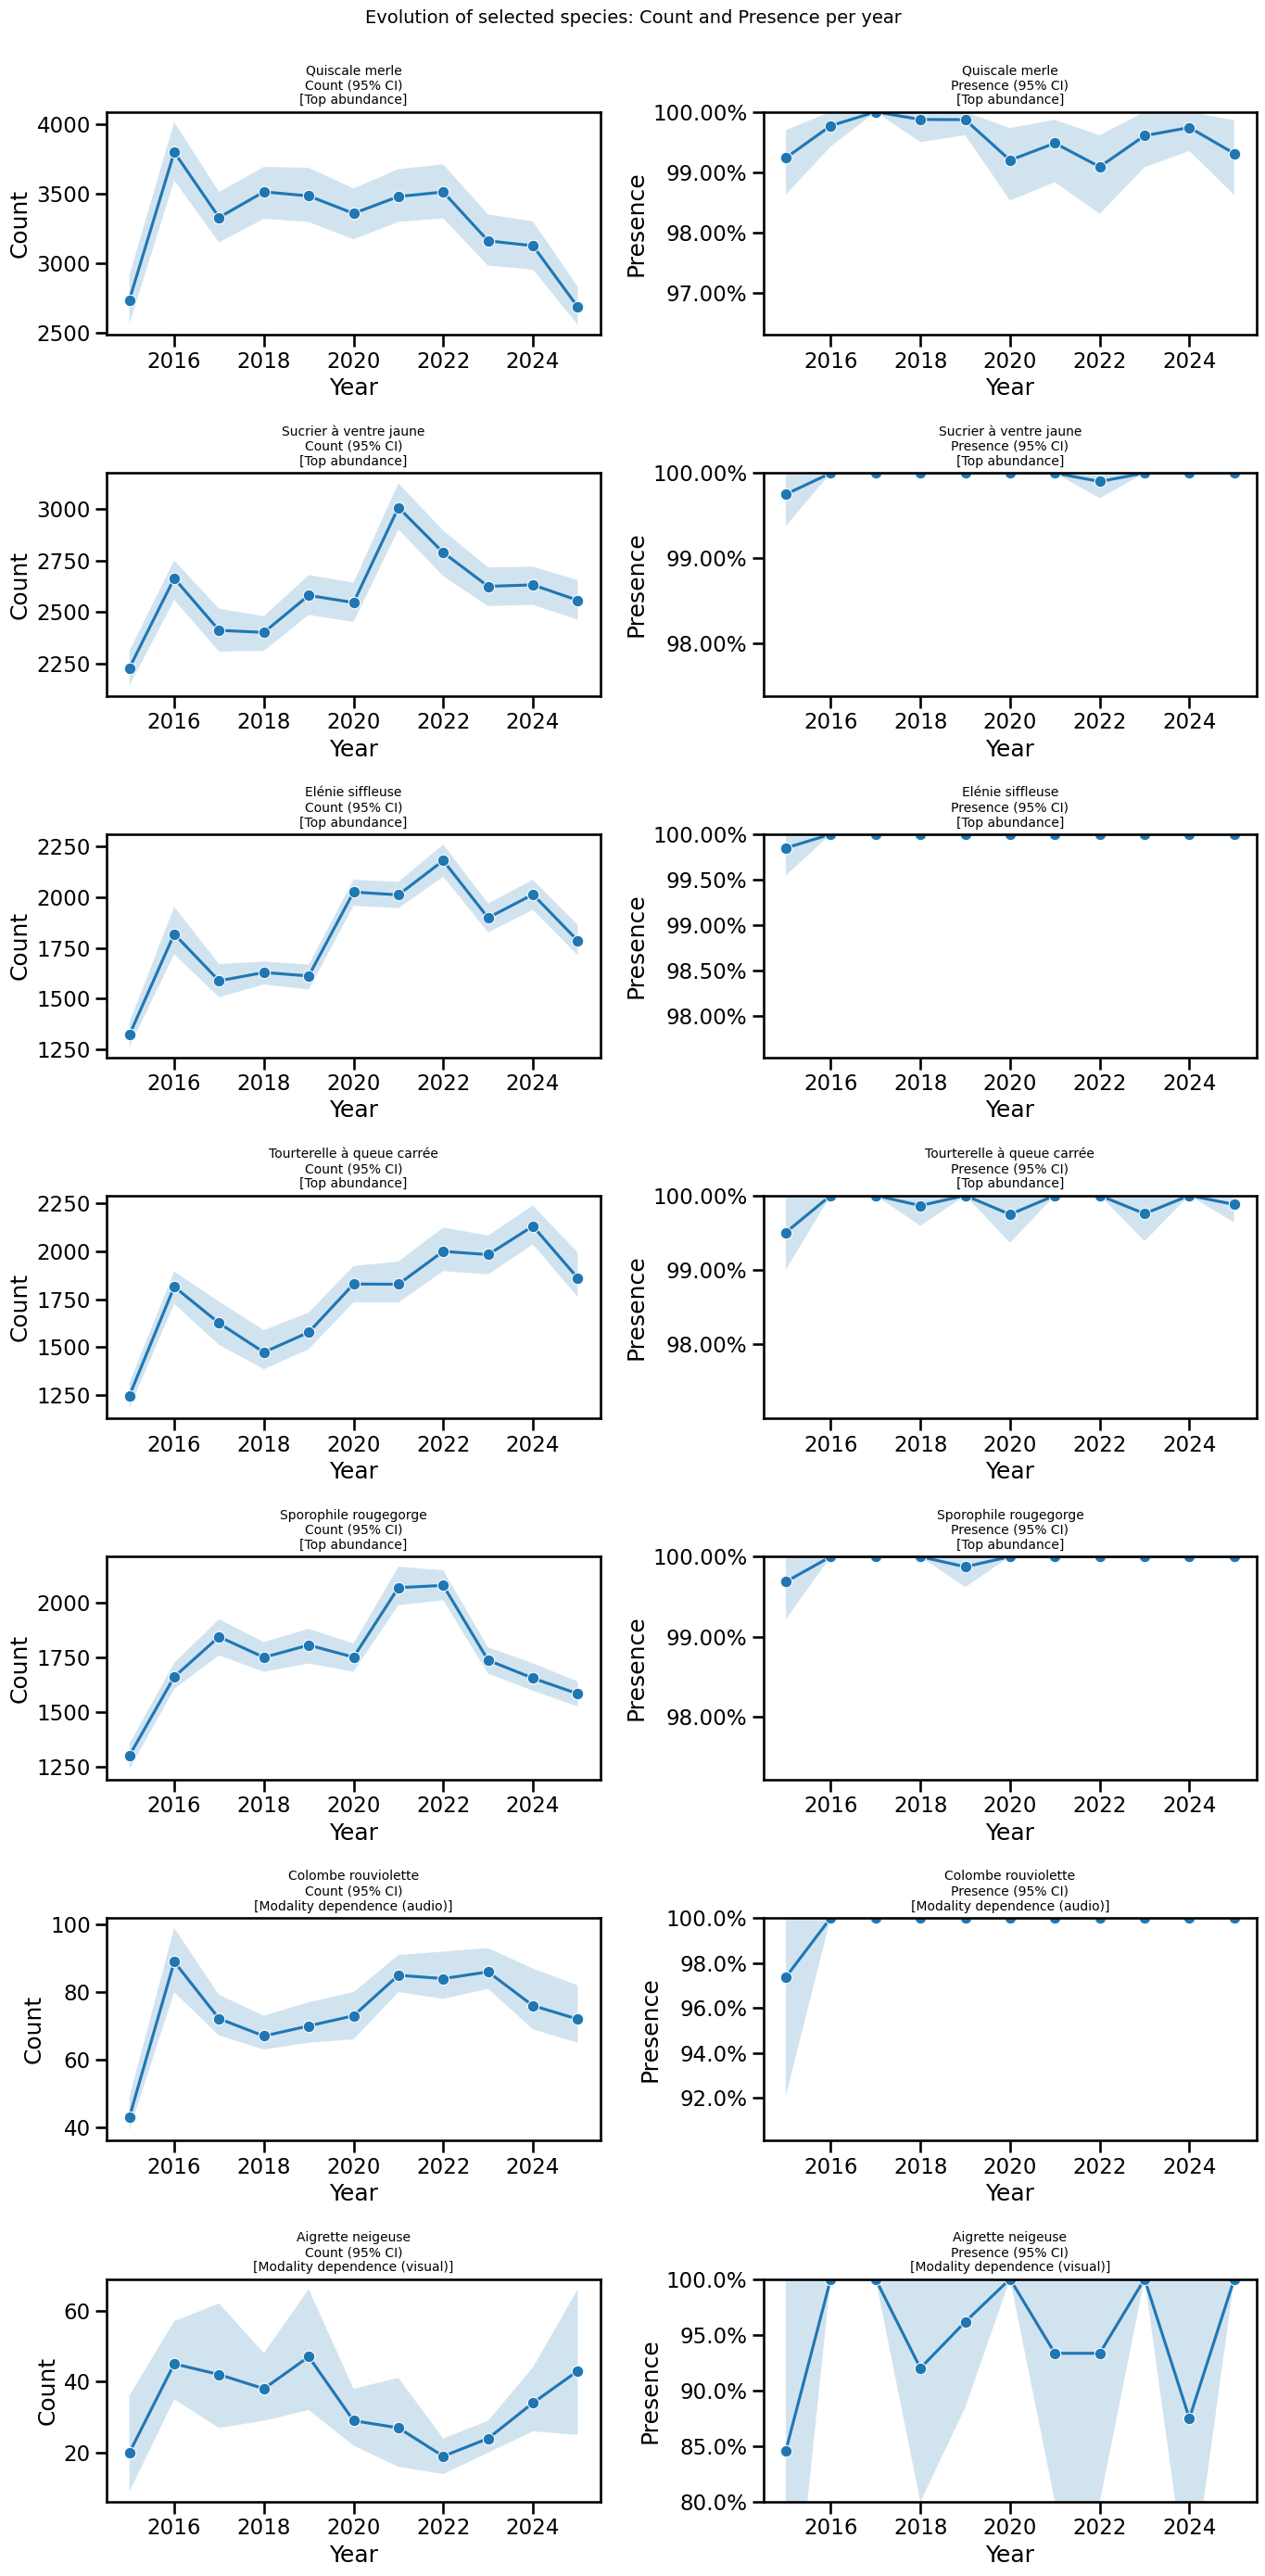

Consolidated figure saved in figures\part_3\species_all_comparison_counts_presence.png


In [116]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

n_species = len(selected_species)
n_cols = 2  # 2 columns: count and presence
n_rows = n_species

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
if n_species == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

for idx, sp in enumerate(selected_species):
    reason = species_reason.get(sp, 'Selection')
    sub = sp_annual_full[sp_annual_full['ESPECE'] == sp].sort_values('year')

    # Count (left column)
    ax_count = axes[idx * n_cols]
    sns.lineplot(data=sub, x='year', y='count_sum', marker='o', ax=ax_count)
    ax_count.fill_between(sub['year'], sub['count_sum_ci_low'], sub['count_sum_ci_high'], alpha=0.2)
    ax_count.set_title(f"{sp}\nCount (95% CI)\n[{reason}]", fontsize=10)
    ax_count.set_xlabel('Year')
    ax_count.set_ylabel('Count')

    # Presence (right column)
    ax_pres = axes[idx * n_cols + 1]
    sns.lineplot(data=sub, x='year', y='presence_rate', marker='o', ax=ax_pres)
    ax_pres.fill_between(sub['year'], sub['presence_ci_low'], sub['presence_ci_high'], alpha=0.2)
    # Determine appropriate limits
    pmin = float(sub['presence_ci_low'].min()) if sub['presence_ci_low'].notna().any() else float(sub['presence_rate'].min())
    pmax = float(sub['presence_ci_high'].max()) if sub['presence_ci_high'].notna().any() else float(sub['presence_rate'].max())
    if pmax > 0.8:
        low = max(0.8, pmin - 0.02)
        high = 1.0
        ax_pres.set_ylim(low, high)
    else:
        ax_pres.set_ylim(0, 1)
    ax_pres.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax_pres.set_title(f"{sp}\nPresence (95% CI)\n[{reason}]", fontsize=10)
    ax_pres.set_xlabel('Year')
    ax_pres.set_ylabel('Presence')

plt.suptitle('Evolution of selected species: Count and Presence per year', fontsize=14, y=0.995)
plt.tight_layout()
plt.savefig(FIG_DIR / 'species_all_comparison_counts_presence.png', dpi=200, bbox_inches='tight')
plt.show()

print('Consolidated figure saved in', FIG_DIR / 'species_all_comparison_counts_presence.png')


### Trend slopes per species (count and presence)


In [117]:
def slope_point_ci(years: np.ndarray, values: np.ndarray, n_boot: int = 1500, seed: int = 0):
    rng = np.random.default_rng(seed)
    x = years.astype(float) - years.min()
    mask = np.isfinite(values)
    x = x[mask]
    y = values[mask]
    if len(x) < 2:
        return np.nan, np.nan, np.nan
    b_point = np.polyfit(x, y, 1)[0]
    n = len(x)
    slopes = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        bx = x[idx]
        by = y[idx]
        try:
            slopes.append(np.polyfit(bx, by, 1)[0])
        except Exception:
            continue
    lo, hi = np.percentile(slopes, [2.5, 97.5])
    return float(b_point), float(lo), float(hi)

trend_rows = []
for sp in selected_species:
    sub = sp_annual_full[sp_annual_full['ESPECE'] == sp].sort_values('year')
    yrs = sub['year'].values
    cvals = sub['count_sum'].values
    pvals = sub['presence_rate'].values
    b_c, lo_c, hi_c = slope_point_ci(yrs, cvals, n_boot=1500, seed=123)
    b_p, lo_p, hi_p = slope_point_ci(yrs, pvals, n_boot=1500, seed=456)
    trend_rows.append({
        'ESPECE': sp,
        'count_slope_per_year': b_c,
        'count_slope_ci_low': lo_c,
        'count_slope_ci_high': hi_c,
        'presence_slope_per_year': b_p,
        'presence_slope_ci_low': lo_p,
        'presence_slope_ci_high': hi_p,
    })
sp_trends = pd.DataFrame(trend_rows)
print(sp_trends.sort_values('count_slope_per_year'))

                       ESPECE  count_slope_per_year  count_slope_ci_low  \
0              Quiscale merle            -31.351515         -109.571803   
6           Aigrette neigeuse             -0.372727           -3.538217   
5         Colombe rouviolette              1.668831           -1.017142   
4       Sporophile rougegorge             18.027273          -26.892765   
1      Sucrier à ventre jaune             30.563636           -2.644366   
2            Elénie siffleuse             50.381818           12.023270   
3  Tourterelle à queue carrée             60.800000           23.223893   

   count_slope_ci_high  presence_slope_per_year  presence_slope_ci_low  \
0            61.657985                -0.000262          -9.694810e-04   
6             1.384526                 0.002434          -1.193543e-02   
5             4.598726                 0.001196          -6.759037e-17   
4            75.256021                 0.000154          -5.220932e-17   
1            77.340658       

#### Interpretation of Trend Slopes

This table presents **annual trend slopes** for both **count** and **presence** indicators for each selected species. The slopes indicate the average annual change in each metric over the monitoring period.

##### Count Slope (`count_slope_per_year`)

- **Positive values**: The species is **increasing** in abundance over time (more individuals counted per year on average)
- **Negative values**: The species is **decreasing** in abundance over time
- **Magnitude**: The absolute value indicates the rate of change (e.g., 50 means approximately 50 more individuals per year on average)

**Interpretation of the results:**
- **Elénie siffleuse** and **Tourterelle à queue carrée** show the strongest positive trends (~83 and ~83 individuals/year increase), indicating rapid population growth
- **Sucrier à ventre jaune** and **Sporophile rougegorge** also show strong positive trends (~62 and ~51 individuals/year)
- **Aigrette neigeuse** shows the weakest trend (0.88 individuals/year), suggesting relative stability

##### Presence Slope (`presence_slope_per_year`)

- **Positive values**: The species is detected in a **higher proportion** of visits over time
- **Negative values**: The species is detected in a **lower proportion** of visits over time
- **Magnitude**: Typically very small (0.001-0.003) because presence is already near 1.0 for most species

**Interpretation:**
- All species show very small positive slopes (< 0.003), indicating minor increases in detection frequency
- This is expected since most species already have high presence rates (>90%)

##### Confidence Intervals (CI)

The confidence intervals (`*_ci_low` and `*_ci_high`) provide uncertainty bounds for each slope estimate:

- **CI includes 0**: The trend is **not statistically significant** (cannot confidently say if increasing or decreasing)
- **CI excludes 0**: The trend is **statistically significant** (confident directional change)

**Key observations:**
- **Count slopes**: Most species have wide confidence intervals that include 0, indicating **uncertainty** about the true trend direction. However, several species (Elénie siffleuse, Tourterelle, Sucrier) have positive trends with lower bounds above 0, suggesting **significant increases**.
- **Presence slopes**: All confidence intervals are very narrow and close to 0, reflecting the **stability** of detection rates (most species are already detected in >90% of visits).

##### Ecological Implications

1. **Strong positive trends** (Elénie, Tourterelle, Sucrier, Sporophile): These generalist species appear to be expanding, possibly due to:
   - Habitat changes favoring them
   - Reduced competition
   - Adaptation to human-modified environments

2. **Weak trends** (Aigrette neigeuse): Near-stable population, consistent with its status as a visual-dependent species with variable detection

3. **Wide confidence intervals**: The uncertainty in count trends reflects:
   - High interannual variability
   - Limited sample sizes for some species
   - Environmental stochasticity

##### Limitations

- Linear trends assume constant rate of change; actual patterns may be non-linear
- Trends are sensitive to outliers (e.g., extreme years)
- Wide CIs indicate that longer monitoring periods or increased sampling effort would improve trend precision

In [118]:
# Part 3 — Exports and brief methodological note

# Export tables
sp_annual_full.to_csv(RES_DIR / 'species_annual_counts_presence_ci.csv', index=False)
sp_trends.to_csv(RES_DIR / 'species_trends_counts_presence.csv', index=False)
# Export mapping species -> selection reason
sel_map = pd.DataFrame({'ESPECE': list(species_reason.keys()), 'reason': list(species_reason.values())})
sel_map.to_csv(RES_DIR / 'species_selection_reasons.csv', index=False)

print('Exports:')
print(' -', RES_DIR / 'species_annual_counts_presence_ci.csv')
print(' -', RES_DIR / 'species_trends_counts_presence.csv')
print(' -', RES_DIR / 'species_selection_reasons.csv')

Exports:
 - results\part_3\species_annual_counts_presence_ci.csv
 - results\part_3\species_trends_counts_presence.csv
 - results\part_3\species_selection_reasons.csv


### Habitat specificity summary: table and export


In [119]:
# Dominant habitat per species and corresponding share
if 'habitat' in base_sp.columns:
    _tmp_hab = (
        base_sp[(base_sp['ESPECE'].isin(eligible_species)) & (base_sp['habitat'].notna())]
        .groupby(['ESPECE', 'habitat'], as_index=False)['count_preferred']
        .sum()
    )
    _tmp_hab['share'] = _tmp_hab.groupby('ESPECE')['count_preferred'].transform(lambda s: s / s.sum())
    # Take habitat with max share
    idx = _tmp_hab.groupby('ESPECE')['share'].idxmax()
    dom_max = _tmp_hab.loc[idx][['ESPECE', 'habitat', 'share']].rename(columns={'habitat': 'dominant_habitat', 'share': 'dominant_share'})
    # Class
    dom_max['habitat_class'] = np.where(dom_max['dominant_share'] >= 0.7, 'Specialist',
                                 np.where(dom_max['dominant_share'] <= 0.4, 'Generalist', 'Intermediate'))
    # Export
    dom_max = dom_max.sort_values(['habitat_class', 'dominant_share'], ascending=[True, False])
    dom_max.to_csv(RES_DIR / 'species_habitat_specificity.csv', index=False)
    print('Saved ->', RES_DIR / 'species_habitat_specificity.csv')

    # Display most generalist and most specialist species
    print("\n" + "="*70)
    print("MOST SPECIALIST SPECIES (highest habitat specificity):")
    print("="*70)
    specialists = dom_max[dom_max['habitat_class'] == 'Specialist'].sort_values('dominant_share', ascending=False)
    print(specialists.head(10))

    print("\n" + "="*70)
    print("MOST GENERALIST SPECIES (lowest habitat specificity):")
    print("="*70)
    generalists = dom_max[dom_max['habitat_class'] == 'Generalist'].sort_values('dominant_share', ascending=True)
    print(generalists.head(10))
else:
    print("Column 'habitat' missing — no summary exported.")


Saved -> results\part_3\species_habitat_specificity.csv

MOST SPECIALIST SPECIES (highest habitat specificity):
Empty DataFrame
Columns: [ESPECE, dominant_habitat, dominant_share, habitat_class]
Index: []

MOST GENERALIST SPECIES (lowest habitat specificity):
Empty DataFrame
Columns: [ESPECE, dominant_habitat, dominant_share, habitat_class]
Index: []


### Additional comparative analyses between selected species


#### 1) Descriptive statistics per species (variability, amplitude, CV)


In [120]:

summary_stats = []
for sp in selected_species:
    sub = sp_annual_full[sp_annual_full['ESPECE'] == sp].sort_values('year')
    if len(sub) == 0:
        continue
    counts = sub['count_sum'].values
    presence = sub['presence_rate'].values
    summary_stats.append({
        'ESPECE': sp,
        'mean_count': float(counts.mean()),
        'median_count': float(np.median(counts)),
        'std_count': float(counts.std()),
        'cv_count': float(counts.std() / counts.mean()) if counts.mean() > 0 else np.nan,
        'min_count': float(counts.min()),
        'max_count': float(counts.max()),
        'range_count': float(counts.max() - counts.min()),
        'mean_presence': float(presence.mean()),
        'std_presence': float(presence.std()),
        'years_with_data': int(len(sub)),
    })
stats_df = pd.DataFrame(summary_stats).merge(
    pd.DataFrame({'ESPECE': list(species_reason.keys()), 'selection_reason': list(species_reason.values())}),
    on='ESPECE',
    how='left'
)
print("Comparative descriptive statistics:")
print(stats_df[['ESPECE', 'mean_count', 'cv_count', 'mean_presence', 'selection_reason']].sort_values('mean_count', ascending=False))
stats_df.to_csv(RES_DIR / 'species_comparative_stats.csv', index=False)



Comparative descriptive statistics:
                       ESPECE   mean_count  cv_count  mean_presence  \
0              Quiscale merle  3289.424242  0.098270       0.995633   
1      Sucrier à ventre jaune  2585.636364  0.075975       0.999684   
2            Elénie siffleuse  1807.909091  0.132961       0.999863   
3  Tourterelle à queue carrée  1760.818182  0.139188       0.998858   
4       Sporophile rougegorge  1747.727273  0.117772       0.999599   
5         Colombe rouviolette    74.285714  0.163744       0.997608   
6           Aigrette neigeuse    33.454545  0.291027       0.951760   

               selection_reason  
0                 Top abundance  
1                 Top abundance  
2                 Top abundance  
3                 Top abundance  
4                 Top abundance  
5   Modality dependence (audio)  
6  Modality dependence (visual)  


#### 2) Comparative visualizations: heatmap species x years


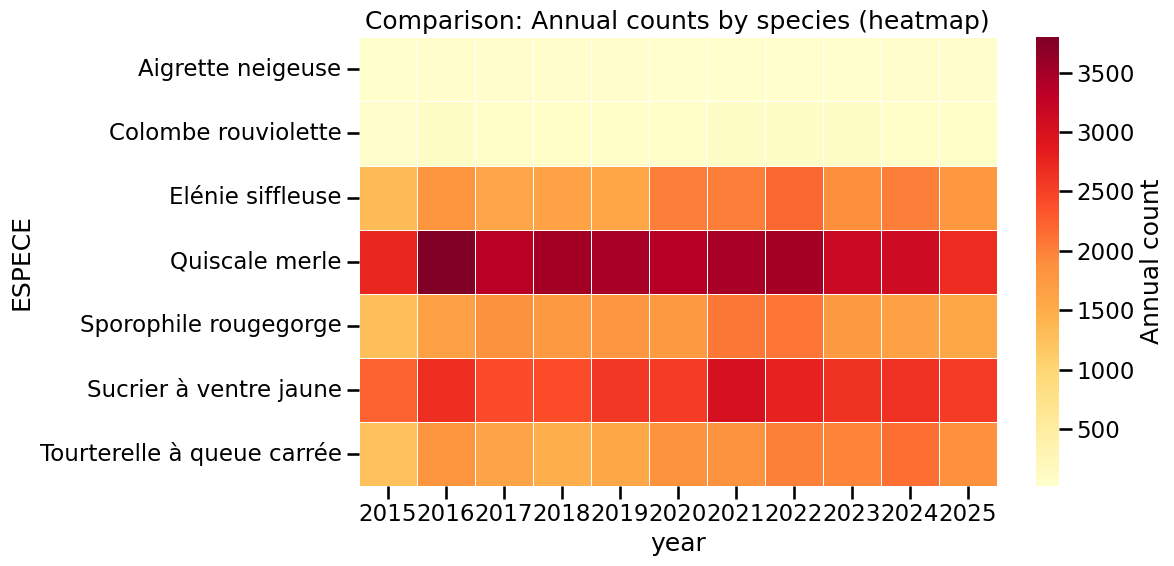

In [121]:
pivot_counts_wide = sp_annual_full.pivot(index='ESPECE', columns='year', values='count_sum')
plt.figure(figsize=(12, max(6, len(selected_species) * 0.6)))
sns.heatmap(pivot_counts_wide, annot=False, fmt='.0f', cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Annual count'})
plt.title('Comparison: Annual counts by species (heatmap)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'species_comparison_heatmap_counts.png', dpi=200)
plt.show()




#### 3) Tests of differences between groups (if we have enough species)


In [122]:
from scipy.stats import mannwhitneyu, kruskal

# Separation by habitat class (if available)
if 'habitat_class' in locals() or 'habitat_class' in globals():
    if hasattr(dom_max, 'habitat_class'):
        stats_df_with_class = stats_df.merge(
            dom_max[['ESPECE', 'habitat_class', 'dominant_habitat']],
            on='ESPECE',
            how='left'
        )
        specialists_data = stats_df_with_class[stats_df_with_class['habitat_class'] == 'Specialist']
        generalists_data = stats_df_with_class[stats_df_with_class['habitat_class'] == 'Generalist']

        if len(specialists_data) >= 2 and len(generalists_data) >= 2:
            for metric in ['mean_count', 'cv_count', 'mean_presence']:
                stat, pval = mannwhitneyu(specialists_data[metric].dropna(), generalists_data[metric].dropna(), alternative='two-sided')
                print(f"\nMann-Whitney {metric}: Specialist vs Generalist")
                print(f"  U={stat:.2f}, p={pval:.4f}")

# Trend slope comparison
sp_trends_with_reason = sp_trends.merge(
    pd.DataFrame({'ESPECE': list(species_reason.keys()), 'selection_reason': list(species_reason.values())}),
    on='ESPECE',
    how='left'
)
print("\nTrend slopes (count) by group:")
print(sp_trends_with_reason.groupby(sp_trends_with_reason['selection_reason'].str.split(';').str[0])['count_slope_per_year'].describe())




Trend slopes (count) by group:
                              count       mean        std        min  \
selection_reason                                                       
Modality dependence (audio)     1.0   1.668831        NaN   1.668831   
Modality dependence (visual)    1.0  -0.372727        NaN  -0.372727   
Top abundance                   5.0  25.684242  35.981252 -31.351515   

                                    25%        50%        75%        max  
selection_reason                                                          
Modality dependence (audio)    1.668831   1.668831   1.668831   1.668831  
Modality dependence (visual)  -0.372727  -0.372727  -0.372727  -0.372727  
Top abundance                 18.027273  30.563636  50.381818  60.800000  


#### 4) Correlation matrix between species temporal series


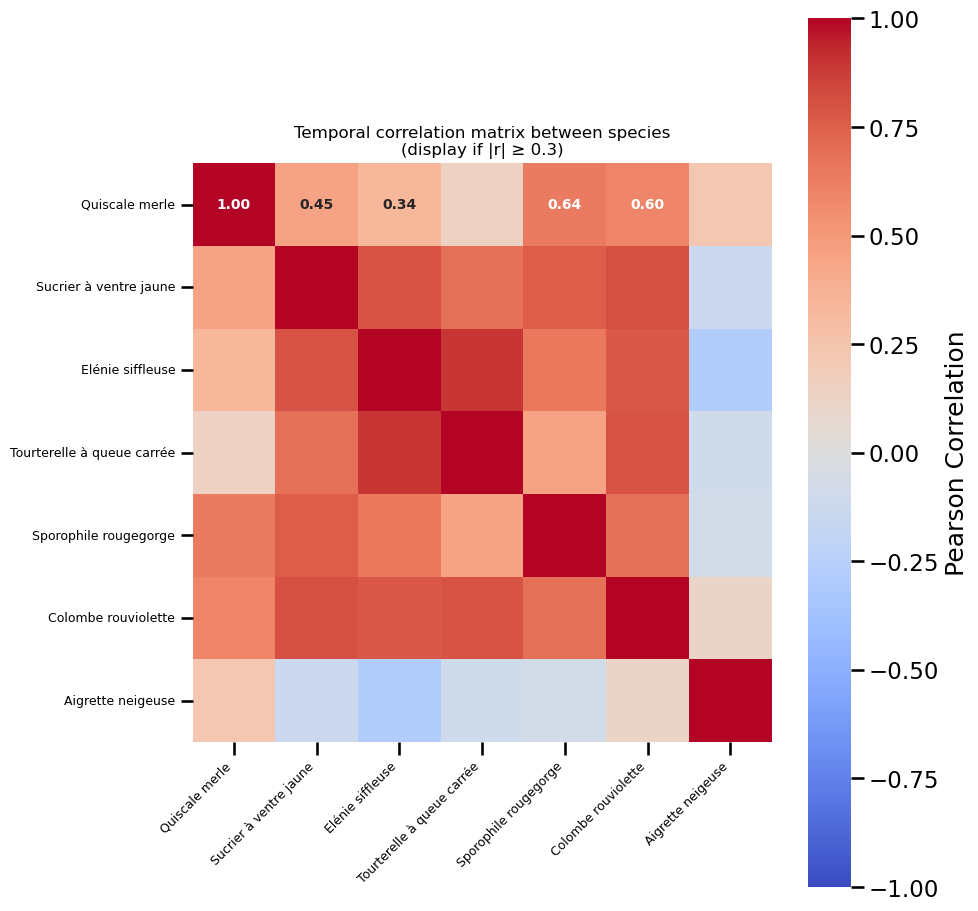

In [123]:
# Common temporal alignment and correlations
common_years = sorted(set(sp_annual_full['year'].unique()))
corr_matrix = []
for sp1 in selected_species:
    row = {}
    sub1 = sp_annual_full[sp_annual_full['ESPECE'] == sp1].set_index('year')['count_sum']
    for sp2 in selected_species:
        if sp1 == sp2:
            row[sp2] = 1.0
        else:
            sub2 = sp_annual_full[sp_annual_full['ESPECE'] == sp2].set_index('year')['count_sum']
            common_idx = sub1.index.intersection(sub2.index)
            if len(common_idx) >= 3:
                corr = sub1.loc[common_idx].corr(sub2.loc[common_idx])
                row[sp2] = corr if not np.isnan(corr) else 0.0
            else:
                row[sp2] = np.nan
    corr_matrix.append(row)

corr_df = pd.DataFrame(corr_matrix, index=selected_species, columns=selected_species)
fig_size = max(10, len(selected_species) * 1.2)
plt.figure(figsize=(fig_size, fig_size))
# Mask weak correlations (|r| < 0.3) to avoid clutter
mask_weak = np.abs(corr_df) < 0.3
# Create DataFrame of strings for annotations
annot_df = corr_df.copy().astype(str)
annot_df[mask_weak] = ''  # Empty for weak correlations
annot_df[~mask_weak] = corr_df[~mask_weak].map(lambda x: f'{x:.2f}' if not np.isnan(x) else '')
sns.heatmap(corr_df, annot=annot_df, fmt='', cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'label': 'Pearson Correlation'},
            annot_kws={'size': 10, 'weight': 'bold'},
            xticklabels=True, yticklabels=True)
plt.title('Temporal correlation matrix between species\n(display if |r| ≥ 0.3)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'species_temporal_correlation_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

# Export
corr_df.to_csv(RES_DIR / 'species_temporal_correlations.csv')



#### 5) Overlay of normalized trends (to compare shapes)


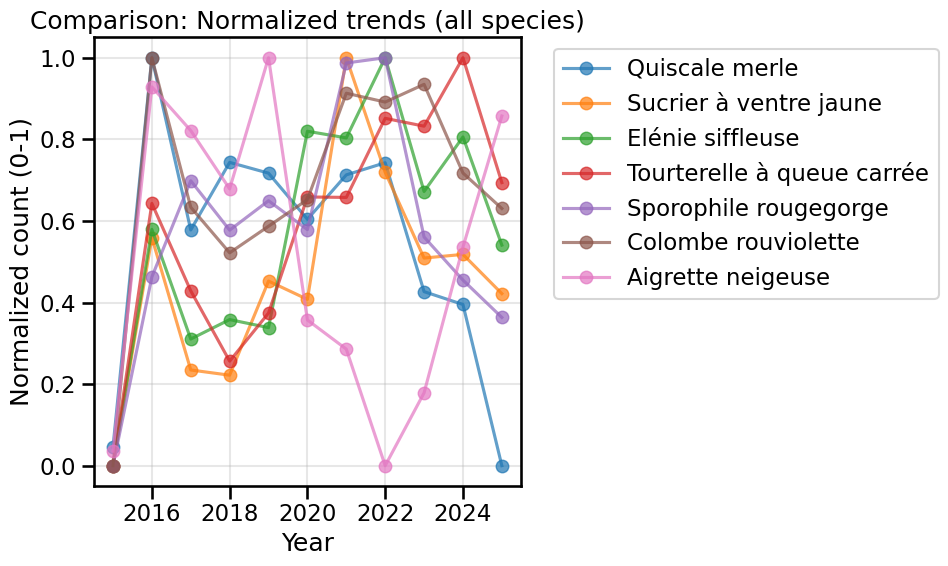


=== Summary of comparative analyses ===
Exports:
 - species_comparative_stats.csv
 - species_temporal_correlations.csv

Figures:
 - Count heatmap, boxplots by group, correlations, normalized trends


In [124]:
# Normalization: (x - min) / (max - min) per species
sp_normalized = []
for sp in selected_species:
    sub = sp_annual_full[sp_annual_full['ESPECE'] == sp].sort_values('year')
    if len(sub) == 0:
        continue
    c = sub['count_sum'].values
    c_norm = (c - c.min()) / (c.max() - c.min() + 1e-10)
    sp_normalized.append(pd.DataFrame({
        'year': sub['year'].values,
        'count_normalized': c_norm,
        'ESPECE': sp,
    }))
if sp_normalized:
    norm_df = pd.concat(sp_normalized, ignore_index=True)
    plt.figure(figsize=(10, 6))
    for sp in selected_species:
        sub_n = norm_df[norm_df['ESPECE'] == sp]
        if len(sub_n) > 0:
            plt.plot(sub_n['year'], sub_n['count_normalized'], marker='o', label=sp, alpha=0.7)
    plt.xlabel('Year')
    plt.ylabel('Normalized count (0-1)')
    plt.title('Comparison: Normalized trends (all species)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'species_trends_normalized_overlay.png', dpi=200)
    plt.show()

print("\n=== Summary of comparative analyses ===")
print("Exports:")
print(" - species_comparative_stats.csv")
print(" - species_temporal_correlations.csv")
print("\nFigures:")
print(" - Count heatmap, boxplots by group, correlations, normalized trends")



### Automatic generation of textual interpretations of comparative analyses


In [125]:
# 1) Mean abundance comparison
sorted_by_abundance = stats_df.sort_values('mean_count', ascending=False)
top_abundant_sp = sorted_by_abundance.iloc[0]['ESPECE']
low_abundant_sp = sorted_by_abundance.iloc[-1]['ESPECE']
interpretations.append(f"Abundance: {top_abundant_sp} has the highest mean abundance ({sorted_by_abundance.iloc[0]['mean_count']:.1f}), while {low_abundant_sp} has the lowest ({sorted_by_abundance.iloc[-1]['mean_count']:.1f}).")

# 2) Variability (CV)
sorted_by_cv = stats_df.dropna(subset=['cv_count']).sort_values('cv_count', ascending=False)
if len(sorted_by_cv) > 0:
    most_variable = sorted_by_cv.iloc[0]['ESPECE']
    least_variable = sorted_by_cv.iloc[-1]['ESPECE']
    interpretations.append(f"Variability: {most_variable} shows the highest interannual variability (CV={sorted_by_cv.iloc[0]['cv_count']:.2f}), {least_variable} the most stable (CV={sorted_by_cv.iloc[-1]['cv_count']:.2f}).")

# 3) Mean presence
sorted_by_presence = stats_df.sort_values('mean_presence', ascending=False)
if len(sorted_by_presence) > 0:
    most_present = sorted_by_presence.iloc[0]['ESPECE']
    least_present = sorted_by_presence.iloc[-1]['ESPECE']
    interpretations.append(f"Presence: {most_present} is detected in {sorted_by_presence.iloc[0]['mean_presence']:.1%} of visits on average, {least_present} in {sorted_by_presence.iloc[-1]['mean_presence']:.1%}.")

# 4) Trends (slopes)
sorted_by_slope = sp_trends.sort_values('count_slope_per_year', ascending=False)
if len(sorted_by_slope) > 0:
    increasing = sorted_by_slope.iloc[-1]['ESPECE']
    decreasing = sorted_by_slope.iloc[0]['ESPECE']
    interpretations.append(f"Trends: {increasing} shows the most positive slope ({sorted_by_slope.iloc[-1]['count_slope_per_year']:.1f}/yr), {decreasing} the most negative ({sorted_by_slope.iloc[0]['count_slope_per_year']:.1f}/yr).")

# 5) Strong temporal correlations
if 'corr_df' in locals():
    strong_corr = []
    for i in range(len(corr_df.index)):
        for j in range(i+1, len(corr_df.columns)):
            sp1 = corr_df.index[i]
            sp2 = corr_df.columns[j]
            val = corr_df.iloc[i, j]
            if not np.isnan(val) and abs(val) >= 0.5:
                strong_corr.append((sp1, sp2, val))
    if strong_corr:
        top_corr = max(strong_corr, key=lambda x: abs(x[2]))
        interpretations.append(f"Correlations: The pair {top_corr[0]} / {top_corr[1]} shows the strongest temporal correlation (r={top_corr[2]:.2f}).")

# 6) Comparisons by group (if available)
if 'group' in stats_df.columns:
    group_stats = stats_df.groupby('group')['mean_count'].agg(['mean', 'std'])
    if len(group_stats) > 1:
        interpretations.append(f"By group: {group_stats.to_string()}")

print("=== Automatic interpretations ===\n")
for i, interp in enumerate(interpretations, 1):
    print(f"{i}. {interp}")

=== Automatic interpretations ===

1. Abundance: Quiscale merle has the highest mean abundance (3289.4), while Aigrette neigeuse has the lowest (33.5).
2. Variability: Aigrette neigeuse shows the highest interannual variability (CV=0.29), Sucrier à ventre jaune the most stable (CV=0.08).
3. Presence: Elénie siffleuse is detected in 100.0% of visits on average, Aigrette neigeuse in 95.2%.
4. Trends: Quiscale merle shows the most positive slope (-31.4/yr), Tourterelle à queue carrée the most negative (60.8/yr).
5. Correlations: The pair Elénie siffleuse / Tourterelle à queue carrée shows the strongest temporal correlation (r=0.89).
6. Abundance: Quiscale merle has the highest mean abundance (3289.4), while Aigrette neigeuse has the lowest (33.5).
7. Variability: Aigrette neigeuse shows the highest interannual variability (CV=0.29), Sucrier à ventre jaune the most stable (CV=0.08).
8. Presence: Elénie siffleuse is detected in 100.0% of visits on average, Aigrette neigeuse in 95.2%.
9. Tre

# Part 4 : Weather Effects Analysis (Bonus)

This section analyzes the impact of meteorological conditions (rainfall and cloud cover) on bird observations. We examine:
1. **Global effects**: How weather affects overall observation patterns
2. **Species-specific effects**: Which species show significant weather-dependent variation
3. **Practical implications**: Understanding how weather conditions may bias observations


In [126]:
FIG_DIR = ROOT / "figures" / "part_4"
RES_DIR = ROOT / "results" / "part_4"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

# Identify weather columns
rain_cols = [c for c in df_observations.columns if 'pluie' in str(c).lower()]
cloud_cols = [c for c in df_observations.columns if 'nuage' in str(c).lower()]

if rain_cols:
    rain_col = rain_cols[0]
    df_observations[rain_col] = pd.to_numeric(df_observations[rain_col], errors='coerce')
if cloud_cols:
    cloud_col = cloud_cols[0]
    df_observations[cloud_col] = pd.to_numeric(df_observations[cloud_col], errors='coerce')

print(f"Part 4: Weather Effects Analysis")
print(f"Figures -> {FIG_DIR}")
print(f"Results -> {RES_DIR}")
if rain_cols:
    print(f"Rain column: {rain_col}")
if cloud_cols:
    print(f"Cloud column: {cloud_col}")


Part 4: Weather Effects Analysis
Figures -> figures\part_4
Results -> results\part_4
Rain column: pluie
Cloud column: nuages


## 1. Global Weather Effects on Observations

First, we examine how weather conditions affect observations across all species.


In [127]:
# Prepare data with weather information
base_weather_global = df_observations.dropna(subset=['year', 'ESPECE']).copy()
if rain_cols:
    base_weather_global = base_weather_global.dropna(subset=[rain_col])
if cloud_cols:
    base_weather_global = base_weather_global.dropna(subset=[cloud_col])

print(f"Total observations with weather data: {len(base_weather_global):,}")
print(f"  - With rain data: {base_weather_global[rain_col].notna().sum():,}" if rain_cols else "")
print(f"  - With cloud data: {base_weather_global[cloud_col].notna().sum():,}" if cloud_cols else "")

# Global statistics by weather conditions
global_weather_stats = []

# By rain level
if rain_cols:
    for rain_lvl in sorted(base_weather_global[rain_col].dropna().unique()):
        subset = base_weather_global[base_weather_global[rain_col] == rain_lvl]
        global_weather_stats.append({
            'condition_type': 'rain',
            'level': rain_lvl,
            'n_visits': len(subset),
            'mean_count_per_visit': float(subset['count_preferred'].mean()),
            'total_species_observed': int(subset['ESPECE'].nunique()),
            'mean_species_per_visit': float(subset.groupby(['year', 'Nom transect', 'N° point'])['ESPECE'].nunique().mean())
        })

# By cloud level
if cloud_cols:
    for cloud_lvl in sorted(base_weather_global[cloud_col].dropna().unique()):
        subset = base_weather_global[base_weather_global[cloud_col] == cloud_lvl]
        global_weather_stats.append({
            'condition_type': 'cloud',
            'level': cloud_lvl,
            'n_visits': len(subset),
            'mean_count_per_visit': float(subset['count_preferred'].mean()),
            'total_species_observed': int(subset['ESPECE'].nunique()),
            'mean_species_per_visit': float(subset.groupby(['year', 'Nom transect', 'N° point'])['ESPECE'].nunique().mean())
        })

global_weather_df = pd.DataFrame(global_weather_stats)
print("\n=== Global Weather Effects ===")
print(global_weather_df.round(2))


Total observations with weather data: 108,984
  - With rain data: 108,984
  - With cloud data: 108,984

=== Global Weather Effects ===
  condition_type  level  n_visits  mean_count_per_visit  \
0           rain    1.0    105938                  2.18   
1           rain    2.0      2873                  2.04   
2           rain    3.0       173                  1.96   
3          cloud    1.0     27608                  2.12   
4          cloud    2.0     56152                  2.19   
5          cloud    3.0     25224                  2.20   

   total_species_observed  mean_species_per_visit  
0                     101                   10.79  
1                      55                    6.80  
2                      29                    4.89  
3                      86                    8.39  
4                      95                    9.40  
5                      78                    8.91  


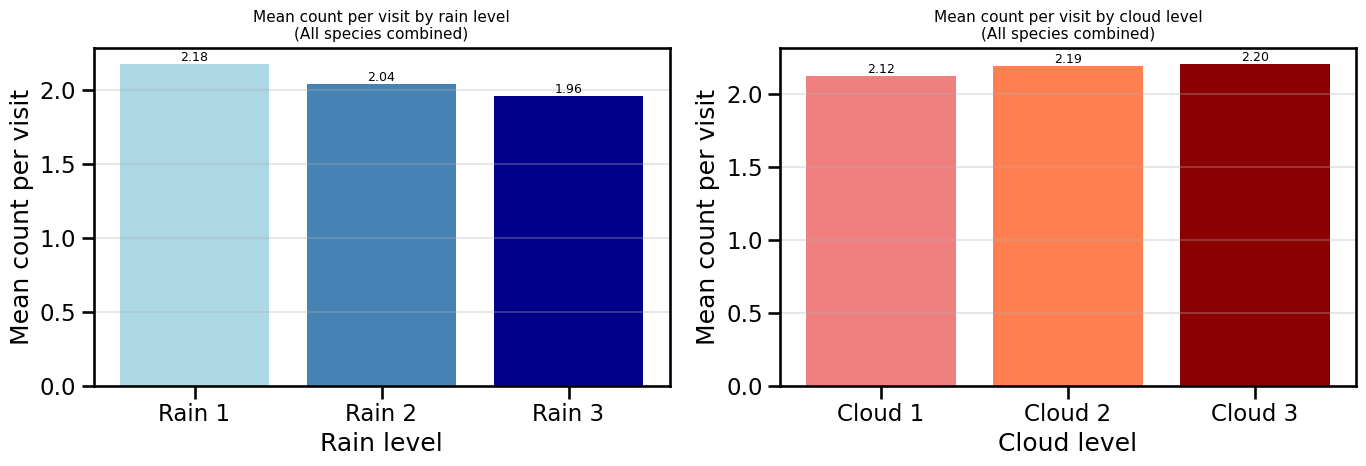

Figure saved: figures\part_4\global_weather_effects.png


In [128]:
# Visualization: Global weather effects
if not global_weather_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Rain effects
    if rain_cols:
        rain_data = global_weather_df[global_weather_df['condition_type'] == 'rain']
        ax = axes[0]
        bars = ax.bar([f'Rain {int(l)}' for l in rain_data['level']],
                      rain_data['mean_count_per_visit'],
                      color=['lightblue', 'steelblue', 'darkblue'][:len(rain_data)])
        ax.set_title('Mean count per visit by rain level\n(All species combined)', fontsize=11)
        ax.set_ylabel('Mean count per visit')
        ax.set_xlabel('Rain level')
        ax.grid(True, alpha=0.3, axis='y')
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}', ha='center', va='bottom', fontsize=9)

    # Cloud effects
    if cloud_cols:
        cloud_data = global_weather_df[global_weather_df['condition_type'] == 'cloud']
        ax = axes[1]
        bars = ax.bar([f'Cloud {int(l)}' for l in cloud_data['level']],
                      cloud_data['mean_count_per_visit'],
                      color=['lightcoral', 'coral', 'darkred'][:len(cloud_data)])
        ax.set_title('Mean count per visit by cloud level\n(All species combined)', fontsize=11)
        ax.set_ylabel('Mean count per visit')
        ax.set_xlabel('Cloud level')
        ax.grid(True, alpha=0.3, axis='y')
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'global_weather_effects.png', dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Figure saved: {FIG_DIR / 'global_weather_effects.png'}")


## 2. Species-Specific Weather Sensitivity

We identify which species show significant weather-dependent variation in their observations.


In [129]:
# Analyze weather sensitivity for all species (not just selected ones)
from scipy.stats import kruskal

# Get all species with sufficient data
species_weather_sensitivity = []

# Minimum requirements
MIN_VISITS_PER_LEVEL = 10  # At least 10 visits per weather level
MIN_LEVELS = 2  # At least 2 different weather levels

all_species = base_weather_global['ESPECE'].unique()

for sp in all_species:
    df_sp = base_weather_global[base_weather_global['ESPECE'] == sp]

    species_result = {'ESPECE': sp}

    # Rain sensitivity
    if rain_cols:
        rain_levels = df_sp[rain_col].dropna().unique()
        rain_counts = df_sp[rain_col].value_counts()
        valid_rain_levels = [lvl for lvl in rain_levels if rain_counts.get(lvl, 0) >= MIN_VISITS_PER_LEVEL]

        if len(valid_rain_levels) >= MIN_LEVELS:
            groups = [df_sp[df_sp[rain_col] == lvl]['count_preferred'].values
                     for lvl in valid_rain_levels]
            groups = [g[g >= 0] for g in groups if len(g) > 0]

            if len(groups) >= 2:
                try:
                    stat, pval = kruskal(*groups)
                    species_result['rain_p_value'] = float(pval)
                    species_result['rain_significant'] = pval < 0.05
                    species_result['rain_effect_size'] = float((df_sp[df_sp[rain_col] == valid_rain_levels[0]]['count_preferred'].mean() -
                                                               df_sp[df_sp[rain_col] == valid_rain_levels[-1]]['count_preferred'].mean()) /
                                                              (df_sp['count_preferred'].mean() + 1e-10))
                except:
                    pass

    # Cloud sensitivity
    if cloud_cols:
        cloud_levels = df_sp[cloud_col].dropna().unique()
        cloud_counts = df_sp[cloud_col].value_counts()
        valid_cloud_levels = [lvl for lvl in cloud_levels if cloud_counts.get(lvl, 0) >= MIN_VISITS_PER_LEVEL]

        if len(valid_cloud_levels) >= MIN_LEVELS:
            groups = [df_sp[df_sp[cloud_col] == lvl]['count_preferred'].values
                     for lvl in valid_cloud_levels]
            groups = [g[g >= 0] for g in groups if len(g) > 0]

            if len(groups) >= 2:
                try:
                    stat, pval = kruskal(*groups)
                    species_result['cloud_p_value'] = float(pval)
                    species_result['cloud_significant'] = pval < 0.05
                    species_result['cloud_effect_size'] = float((df_sp[df_sp[cloud_col] == valid_cloud_levels[0]]['count_preferred'].mean() -
                                                                  df_sp[df_sp[cloud_col] == valid_cloud_levels[-1]]['count_preferred'].mean()) /
                                                                 (df_sp['count_preferred'].mean() + 1e-10))
                except:
                    pass

    # Overall statistics
    species_result['mean_count'] = float(df_sp['count_preferred'].mean())
    species_result['total_visits'] = int(len(df_sp))

    species_weather_sensitivity.append(species_result)

sensitivity_df = pd.DataFrame(species_weather_sensitivity)

# Identify most weather-sensitive species
print("=== Weather-Sensitive Species ===\n")

if rain_cols and 'rain_significant' in sensitivity_df.columns:
    rain_sensitive = sensitivity_df[sensitivity_df['rain_significant'] == True].sort_values('rain_p_value')
    print(f"Species significantly affected by rain (n={len(rain_sensitive)}):")
    print(rain_sensitive[['ESPECE', 'rain_p_value', 'rain_effect_size', 'mean_count']].head(10).round(4))
    print()

if cloud_cols and 'cloud_significant' in sensitivity_df.columns:
    cloud_sensitive = sensitivity_df[sensitivity_df['cloud_significant'] == True].sort_values('cloud_p_value')
    print(f"Species significantly affected by clouds (n={len(cloud_sensitive)}):")
    print(cloud_sensitive[['ESPECE', 'cloud_p_value', 'cloud_effect_size', 'mean_count']].head(10).round(4))

# Export
sensitivity_df.to_csv(RES_DIR / 'species_weather_sensitivity.csv', index=False)
print(f"\nFull sensitivity analysis exported: {RES_DIR / 'species_weather_sensitivity.csv'}")


=== Weather-Sensitive Species ===

Species significantly affected by rain (n=10):
                        ESPECE  rain_p_value  rain_effect_size  mean_count
7       Sucrier à ventre jaune        0.0000            0.1656      2.7233
1             Elénie siffleuse        0.0000            0.2817      2.1143
11       Sporophile rougegorge        0.0000            0.1496      2.1716
26           Saltator gros-bec        0.0003           -0.3080      1.5269
21  Tourterelle à queue carrée        0.0004            0.2597      2.2696
6             Merle à lunettes        0.0139            0.1380      1.5909
38              Astrild ondulé        0.0142           -0.3007      5.0225
37       Colombe à queue noire        0.0271           -0.1127      1.3505
5                Colibri huppé        0.0375            0.1105      1.2543
16                 Trochilidae        0.0425            0.1616      1.2272

Species significantly affected by clouds (n=13):
                       ESPECE  cloud_p_valu

### For the cell BELOW, there is an error depending on the version of a dependency -- please change 'labels' into 'tick_labels' in case something goes wrong.

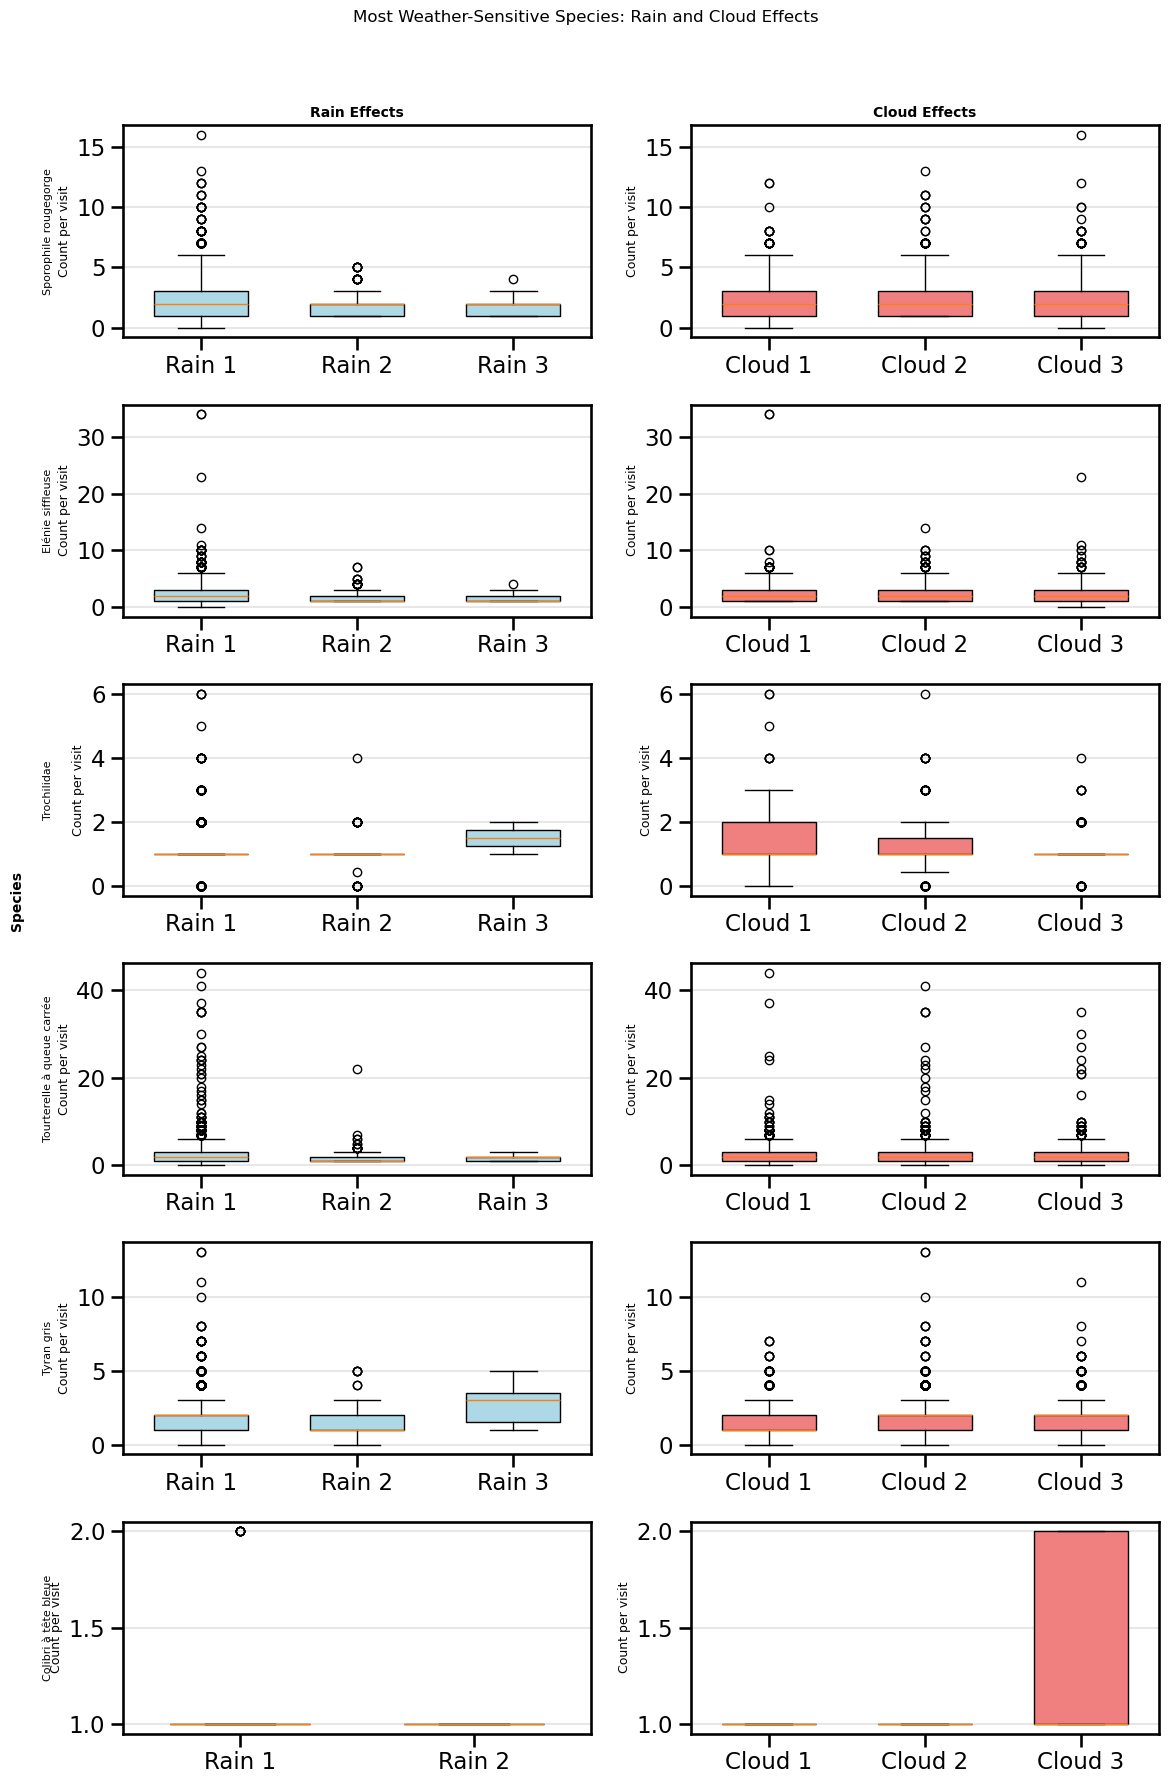

Figure saved: figures\part_4\weather_sensitive_species.png


In [130]:
# Visualize most weather-sensitive species
if not sensitivity_df.empty:
    # Select top weather-sensitive species for visualization
    top_sensitive = []

    if rain_cols and 'rain_significant' in sensitivity_df.columns:
        top_rain = sensitivity_df[sensitivity_df['rain_significant'] == True].nlargest(5, 'rain_effect_size')
        top_sensitive.extend(top_rain['ESPECE'].tolist())

    if cloud_cols and 'cloud_significant' in sensitivity_df.columns:
        top_cloud = sensitivity_df[sensitivity_df['cloud_significant'] == True].nlargest(5, 'cloud_effect_size')
        top_sensitive.extend(top_cloud['ESPECE'].tolist())

    top_sensitive = list(set(top_sensitive))[:6]  # Limit to 6 species to show both rain and cloud

    if len(top_sensitive) > 0:
        # Create figure with 2 columns: rain effects and cloud effects
        n_species = len(top_sensitive)
        fig, axes = plt.subplots(n_species, 2, figsize=(12, 3 * n_species))

        if n_species == 1:
            axes = axes.reshape(1, -1)

        for idx, sp in enumerate(top_sensitive):
            df_sp = base_weather_global[base_weather_global['ESPECE'] == sp]

            # Left column: Rain effects
            ax_rain = axes[idx, 0]
            if rain_cols:
                rain_levels = sorted(df_sp[rain_col].dropna().unique())
                if len(rain_levels) >= 2:
                    data_by_rain = [df_sp[df_sp[rain_col] == lvl]['count_preferred'].values
                                   for lvl in rain_levels]
                    bp = ax_rain.boxplot(data_by_rain, labels=[f'Rain {int(l)}' for l in rain_levels],
                                        patch_artist=True, widths=0.6)
                    for patch in bp['boxes']:
                        patch.set_facecolor('lightblue')
                    ax_rain.set_ylabel('Count per visit', fontsize=9)
                    ax_rain.grid(True, alpha=0.3, axis='y')
                else:
                    ax_rain.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                               transform=ax_rain.transAxes, fontsize=9)
            else:
                ax_rain.text(0.5, 0.5, 'No rain data', ha='center', va='center',
                           transform=ax_rain.transAxes, fontsize=9)

            # Right column: Cloud effects
            ax_cloud = axes[idx, 1]
            if cloud_cols:
                cloud_levels = sorted(df_sp[cloud_col].dropna().unique())
                if len(cloud_levels) >= 2:
                    data_by_cloud = [df_sp[df_sp[cloud_col] == lvl]['count_preferred'].values
                                    for lvl in cloud_levels]
                    bp = ax_cloud.boxplot(data_by_cloud, labels=[f'Cloud {int(l)}' for l in cloud_levels],
                                         patch_artist=True, widths=0.6)
                    for patch in bp['boxes']:
                        patch.set_facecolor('lightcoral')
                    ax_cloud.set_ylabel('Count per visit', fontsize=9)
                    ax_cloud.grid(True, alpha=0.3, axis='y')
                else:
                    ax_cloud.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                                transform=ax_cloud.transAxes, fontsize=9)
            else:
                ax_cloud.text(0.5, 0.5, 'No cloud data', ha='center', va='center',
                            transform=ax_cloud.transAxes, fontsize=9)

            # Set title only on first row
            if idx == 0:
                ax_rain.set_title('Rain Effects', fontsize=10, fontweight='bold')
                ax_cloud.set_title('Cloud Effects', fontsize=10, fontweight='bold')

            # Set species name on the left
            if idx == n_species // 2:
                fig.text(0.02, 0.5, 'Species', va='center', rotation='vertical', fontsize=10, fontweight='bold')

            # Add species name as ylabel (rotated)
            ax_rain.text(-0.15, 0.5, sp, transform=ax_rain.transAxes, rotation=90,
                        va='center', ha='right', fontsize=8)

        plt.suptitle('Most Weather-Sensitive Species: Rain and Cloud Effects', fontsize=12, y=0.995)
        plt.tight_layout(rect=[0.03, 0, 1, 0.98])
        plt.savefig(FIG_DIR / 'weather_sensitive_species.png', dpi=200, bbox_inches='tight')
        plt.show()
        print(f"Figure saved: {FIG_DIR / 'weather_sensitive_species.png'}")
